# PetFinder — Modelo Tabular
**Maestría en Ciencia de Datos — Laboratorio de Implementación**

Este notebook cubre tres etapas en secuencia:
1. **Baseline** — LightGBM con features crudas, sin ingeniería
2. **Feature Engineering iterativo** — creación y evaluación incremental de variables
3. **Tuning** — optimización de hiperparámetros con Optuna

**Métrica principal:** Cohen's Kappa Cuadrático (QWK)  
**Métricas de seguimiento:** accuracy por clase, F1 macro  
**Validación:** StratifiedKFold(n_splits=5)

---
## 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import re
import time
from collections import defaultdict

# Modelado
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2', 5)

SEED  = 42
TARGET = 'AdoptionSpeed'
N_FOLDS = 5
np.random.seed(SEED)

print('Librerías cargadas OK')
print(f'LightGBM version: {lgb.__version__}')

Librerías cargadas OK
LightGBM version: 4.6.0


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
input_path = '/kaggle/input/competitions/petfinder-adoption-prediction/'

train  = pd.read_csv(os.path.join(input_path, 'train/train.csv'))
breeds = pd.read_csv(os.path.join(input_path, 'breed_labels.csv'))
colors = pd.read_csv(os.path.join(input_path, 'color_labels.csv'))
states = pd.read_csv(os.path.join(input_path, 'state_labels.csv'))

print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
train.head(2)

Train: 14,993 filas × 24 columnas


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0


---
## 1. Preprocesamiento base

Esta sección replica el preprocesamiento del EDA: limpieza de `Name` y `Description`, merge con labels de razas, y variables derivadas. Se encapsula en una función para poder aplicarla de forma idéntica en cada experimento.

In [4]:
def preprocess_base(df_raw, breeds, colors, states):
    """
    Preprocesamiento base idéntico al EDA.
    Retorna un DataFrame limpio con labels y variables derivadas básicas.
    """
    df = df_raw.copy()

    # ── Limpieza de Name ──────────────────────────────────────────────────────
    invalid_kw = ['adoption','urgent','none','unknown','name','nan','n/a','yet','help']
    df['Name'] = df['Name'].astype(str).str.lower().str.strip()
    mask_name = (
        df['Name'].str.contains('|'.join(invalid_kw), na=False) |
        (df['Name'].str.len() <= 1) |
        df['Name'].str.match(r'^[^a-zA-Z0-9]+$') |
        df['Name'].str.isnumeric() |
        (df['Name'] == 'nan')
    )
    df.loc[mask_name, 'Name'] = np.nan

    # ── Limpieza de Description ───────────────────────────────────────────────
    generic_phrases = ['adoption','to be adopted','looking for a home','please','available','urgent']
    mask_kw    = df['Description'].str.lower().str.contains('|'.join(generic_phrases), na=False)
    mask_short = df['Description'].str.len() < 40
    df.loc[mask_kw & mask_short, 'Description'] = np.nan
    df['Description'] = df['Description'].str.strip()
    df.loc[df['Description'].str.len() < 5, 'Description'] = np.nan

    # ── Merge con labels de razas ─────────────────────────────────────────────
    breeds_ = breeds.copy()
    breeds_['Type']    = breeds_['Type'].astype(int)
    breeds_['BreedID'] = breeds_['BreedID'].astype(int)
    df['Type']   = df['Type'].astype(int)
    df['Breed1'] = df['Breed1'].astype(int)
    df['Breed2'] = df['Breed2'].astype(int)

    df = df.merge(breeds_, left_on=['Type','Breed1'], right_on=['Type','BreedID'], how='left')
    df.rename(columns={'BreedName': 'Breed1Name'}, inplace=True)
    df.drop(columns=['BreedID'], inplace=True)

    df = df.merge(breeds_, left_on=['Type','Breed2'], right_on=['Type','BreedID'], how='left')
    df.rename(columns={'BreedName': 'Breed2Name'}, inplace=True)
    df.drop(columns=['BreedID'], inplace=True)

    # ── Mapeos ────────────────────────────────────────────────────────────────
    color_map = colors.set_index('ColorID')['ColorName'].to_dict()
    state_map = states.set_index('StateID')['StateName'].to_dict()
    df['StateName']   = df['State'].map(state_map)
    df['Color1Label'] = df['Color1'].map(color_map)

    # ── Variables derivadas base ──────────────────────────────────────────────
    df['HasName']    = df['Name'].notna().astype(int)
    df['HasDesc']    = df['Description'].notna().astype(int)
    df['HasPhoto']   = (df['PhotoAmt'].fillna(0) > 0).astype(int)
    df['HasVideo']   = (df['VideoAmt'].fillna(0) > 0).astype(int)
    df['IsFree']     = (df['Fee'] == 0).astype(int)
    df['MixedBreed'] = (
        (df['Breed2Name'].notna() & (df['Breed1'] != df['Breed2'])) |
        (df['Breed1Name'] == 'Mixed Breed')
    ).astype(int)
    df['MixedColor']  = ((df['Color2'] != 0) & df['Color2'].notna()).astype(int)
    df['IsGroup']     = (df['Quantity'] > 1).astype(int)
    df['NameLength']  = df['Name'].str.len().fillna(0)
    df['DescLength']  = df['Description'].str.len().fillna(0)
    df['DescWordCnt'] = df['Description'].fillna('').str.split().str.len()
    df['RescuerFreq'] = df.groupby('RescuerID')['PetID'].transform('count')

    # Variables de estado
    state_pop_map = {41336:9484,41325:5793,41367:5265,41401:13985,41415:8555,
                     41324:8686,41332:7305,41335:6066,41330:6173,41380:5996,
                     41327:9152,41345:6498,41342:6947,41326:13296,41361:7627}
    #poverty_map   = {41336:0.025,41325:0.084,41367:0.115,41401:0.01,41415:0.02,
    #                 41324:0.03,41332:0.04,41335:0.059,41330:0.069,41380:0.036,
    #                 41327:0.019,41345:0.177,41342:0.084,41326:0.009,41361:0.048}
    income_map    = {41336:4206,41325:2228,41367:1908,41401:2074,41415:1010,
                     41324:1053,41332:1245,41335:1678,41330:2575,41380:2980,
                     41327:1803,41345:3760,41342:2530,41326:7407,41361:1247}
    df['StatePop']        = df['State'].map(state_pop_map)
    #df['StatePovertyPct'] = df['State'].map(poverty_map)
    df['StateIncomeAvg']  = df['State'].map(income_map)

    return df


df = preprocess_base(train, breeds, colors, states)
print(f'Dataset preprocesado: {df.shape}')
df.head(2)

Dataset preprocesado: (14993, 42)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,IsFree,MixedBreed,MixedColor,IsGroup,NameLength,DescLength,DescWordCnt,RescuerFreq,StatePop,StateIncomeAvg
0,2,nibble,3,299,0,1,1,7,0,1,...,0,0,1,0,6.0,359.0,69,8,13296,7407
1,2,NaN,1,265,0,1,1,2,0,2,...,1,0,1,0,0.0,118.0,23,1,13985,2074


---
## 2. Infraestructura de evaluación

Antes de entrenar cualquier modelo, definimos las herramientas de evaluación que se reutilizan en cada experimento:
- `run_cv`: entrena con StratifiedKFold(5) y retorna métricas por fold
- `plot_results`: visualiza confusión y distribución de predicciones
- `ExperimentTracker`: registra todos los experimentos para comparación final

In [5]:
def qwk(y_true, y_pred):
    """Cohen's Kappa Cuadrático."""
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


def run_cv(X, y, params, n_folds=N_FOLDS, verbose=True, experiment_name='exp'):
    """
    Entrena LightGBM con StratifiedKFold y retorna métricas agregadas.
    Todo preprocesamiento que dependa del target (target encoding, etc.)
    debe hacerse DENTRO del loop de folds.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

    fold_qwk, fold_acc, fold_f1 = [], [], []
    oof_preds = np.zeros(len(y))
    feat_imp  = np.zeros(X.shape[1])

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params, random_state=SEED)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

        preds = model.predict(X_val)
        oof_preds[val_idx] = preds

        fold_qwk.append(qwk(y_val, preds))
        fold_acc.append(accuracy_score(y_val, preds))
        fold_f1.append(f1_score(y_val, preds, average='macro'))
        feat_imp += model.booster_.feature_importance(importance_type='gain') / n_folds

        if verbose:
            print(f'  Fold {fold+1}: QWK={fold_qwk[-1]:.4f}  '
                  f'Acc={fold_acc[-1]:.4f}  F1={fold_f1[-1]:.4f}  '
                  f'(best iter={model.best_iteration_})')

    results = {
        'name'      : experiment_name,
        'qwk_mean'  : np.mean(fold_qwk),
        'qwk_std'   : np.std(fold_qwk),
        'acc_mean'  : np.mean(fold_acc),
        'f1_mean'   : np.mean(fold_f1),
        'oof_preds' : oof_preds,
        'feat_imp'  : pd.Series(feat_imp, index=X.columns).sort_values(ascending=False),
        'fold_qwk'  : fold_qwk,
    }

    if verbose:
        print(f'\n  ► {experiment_name}')
        print(f'    QWK  {results["qwk_mean"]:.4f} ± {results["qwk_std"]:.4f}')
        print(f'    Acc  {results["acc_mean"]:.4f}')
        print(f'    F1   {results["f1_mean"]:.4f}')

    return results


class ExperimentTracker:
    """Registra todos los experimentos para comparación."""
    def __init__(self):
        self.records = []

    def log(self, result):
        self.records.append({
            'Experimento' : result['name'],
            'QWK'         : round(result['qwk_mean'], 4),
            'QWK±std'     : round(result['qwk_std'], 4),
            'Accuracy'    : round(result['acc_mean'], 4),
            'F1 macro'    : round(result['f1_mean'], 4),
        })

    def table(self):
        df_t = pd.DataFrame(self.records)
        return df_t.sort_values('QWK', ascending=False).reset_index(drop=True)

    def plot(self):
        df_t = self.table()
        fig, ax = plt.subplots(figsize=(10, 0.55 * len(df_t) + 2))
        colors_bar = [PALETTE[0] if i == 0 else PALETTE[2] for i in range(len(df_t))]
        bars = ax.barh(df_t['Experimento'][::-1], df_t['QWK'][::-1],
                       color=colors_bar[::-1], edgecolor='white')
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.set_title('Comparación de experimentos — QWK (CV)', fontweight='bold')
        ax.set_xlabel('QWK medio (5-fold)')
        ax.set_xlim(0, df_t['QWK'].max() + 0.05)
        plt.tight_layout()
        plt.show()


tracker = ExperimentTracker()
print('Infraestructura lista.')

Infraestructura lista.


In [6]:
def plot_results(y_true, oof_preds, title=''):
    """Matriz de confusión + distribución real vs. predicha."""
    preds = oof_preds.astype(int)
    labels = ['0\nMismo día','1\n1–7d','2\n8–30d','3\n31–90d','4\nNo adopt.']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Matriz de confusión normalizada por fila (recall por clase)
    cm = confusion_matrix(y_true, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    axes[0].set_title(f'Matriz de confusión (recall por fila)\nQWK={qwk(y_true, preds):.4f}  Acc={accuracy_score(y_true, preds):.4f}')
    axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicho')

    # Distribución real vs. predicha
    classes = [0, 1, 2, 3, 4]
    x = np.arange(len(classes))
    w = 0.35
    r_counts = [(y_true == c).sum() for c in classes]
    p_counts = [(preds == c).sum() for c in classes]
    axes[1].bar(x - w/2, r_counts, w, label='Real',    color=PALETTE[0], edgecolor='white')
    axes[1].bar(x + w/2, p_counts, w, label='Predicho', color=PALETTE[2], edgecolor='white')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(['0','1','2','3','4'])
    axes[1].set_title('Distribución real vs. predicha')
    axes[1].set_ylabel('Cantidad'); axes[1].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, preds,
          target_names=['0-MismoDía','1-1ªSemana','2-1erMes','3-2do3erMes','4-NoAdopt.']))


def plot_importance(feat_imp, top_n=20, title='Feature Importance (gain medio)'):
    top = feat_imp.head(top_n)
    fig, ax = plt.subplots(figsize=(9, top_n * 0.3 + 1))
    ax.barh(top.index[::-1], top.values[::-1], color=PALETTE[0], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importancia media (gain)')
    plt.tight_layout()
    plt.show()

print('Funciones de visualización listas.')

Funciones de visualización listas.


---
## 3. Baseline — LightGBM sin Feature Engineering

Objetivo: establecer un piso de performance usando únicamente las features numéricas y categóricas crudas del dataset, sin ninguna transformación adicional. Este número sirve como referencia para evaluar si cada feature nueva agrega valor real.

In [7]:
# ── Features del baseline: columnas originales crudas ─────────────────────────
BASELINE_FEATURES = [
    # Numéricas originales
    'Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt',
    # Categóricas ordinales (como enteros)
    'Type', 'Gender', 'Color1', 'Color2', 'Color3',
    'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
    'Health', 'State', 'Breed1', 'Breed2',
    # Derivadas base (no requieren FE)
    'HasName', 'HasDesc', 'HasPhoto', 'HasVideo', 'IsFree',
    'MixedBreed', 'MixedColor', 'IsGroup',
    'NameLength', 'DescLength', 'DescWordCnt',
    'RescuerFreq',
    'StatePop', 'StateIncomeAvg' #, 'StatePovertyPct'
    
]

BASELINE_PARAMS = {
    'objective'     : 'multiclass',
    'num_class'     : 5,
    'metric'        : 'multi_logloss',
    'n_estimators'  : 2000,
    'learning_rate' : 0.05,
    'num_leaves'    : 63,
    'min_child_samples': 20,
    'subsample'     : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'     : 0.1,
    'reg_lambda'    : 0.1,
    'verbose'       : -1,
}

X_base = df[BASELINE_FEATURES].copy()
y      = df[TARGET].copy()

print(f'Shape baseline: {X_base.shape}')
print(f'Features: {BASELINE_FEATURES}')

Shape baseline: (14993, 33)
Features: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'Type', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Breed1', 'Breed2', 'HasName', 'HasDesc', 'HasPhoto', 'HasVideo', 'IsFree', 'MixedBreed', 'MixedColor', 'IsGroup', 'NameLength', 'DescLength', 'DescWordCnt', 'RescuerFreq', 'StatePop', 'StateIncomeAvg']


In [8]:
print('=' * 55)
print('EXPERIMENTO 0: BASELINE')
print('=' * 55)

result_baseline = run_cv(X_base, y, BASELINE_PARAMS, experiment_name='00_baseline')
tracker.log(result_baseline)

EXPERIMENTO 0: BASELINE
  Fold 1: QWK=0.3652  Acc=0.4261  F1=0.3476  (best iter=138)
  Fold 2: QWK=0.3888  Acc=0.4415  F1=0.3747  (best iter=105)
  Fold 3: QWK=0.4126  Acc=0.4438  F1=0.3469  (best iter=102)
  Fold 4: QWK=0.3721  Acc=0.4396  F1=0.3390  (best iter=88)
  Fold 5: QWK=0.4046  Acc=0.4480  F1=0.3584  (best iter=105)

  ► 00_baseline
    QWK  0.3887 ± 0.0182
    Acc  0.4398
    F1   0.3533


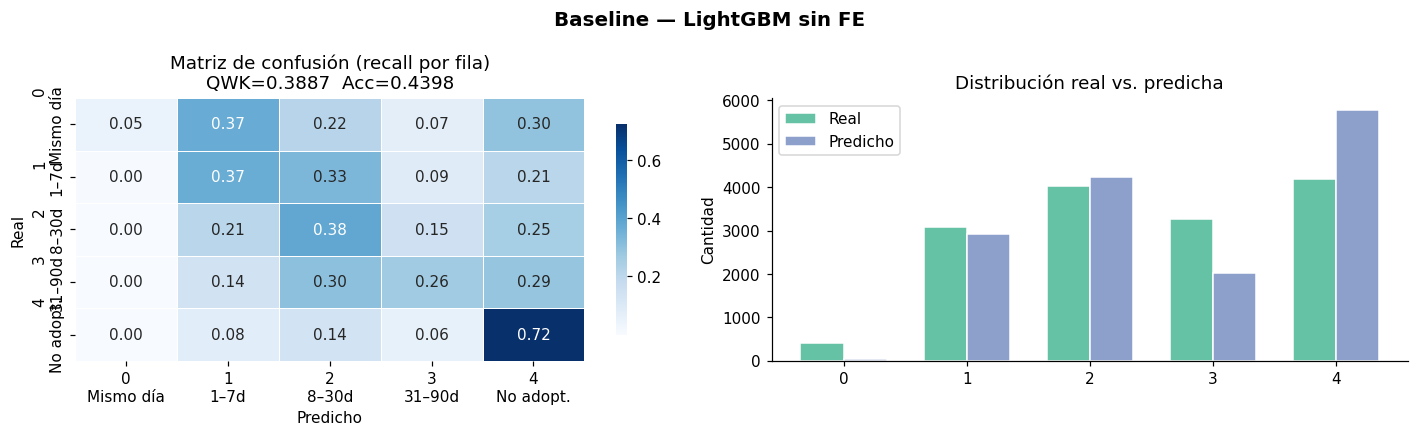

              precision    recall  f1-score   support

  0-MismoDía       0.40      0.05      0.08       410
  1-1ªSemana       0.39      0.37      0.38      3090
    2-1erMes       0.37      0.38      0.37      4037
 3-2do3erMes       0.43      0.26      0.33      3259
  4-NoAdopt.       0.53      0.72      0.61      4197

    accuracy                           0.44     14993
   macro avg       0.42      0.36      0.35     14993
weighted avg       0.43      0.44      0.42     14993



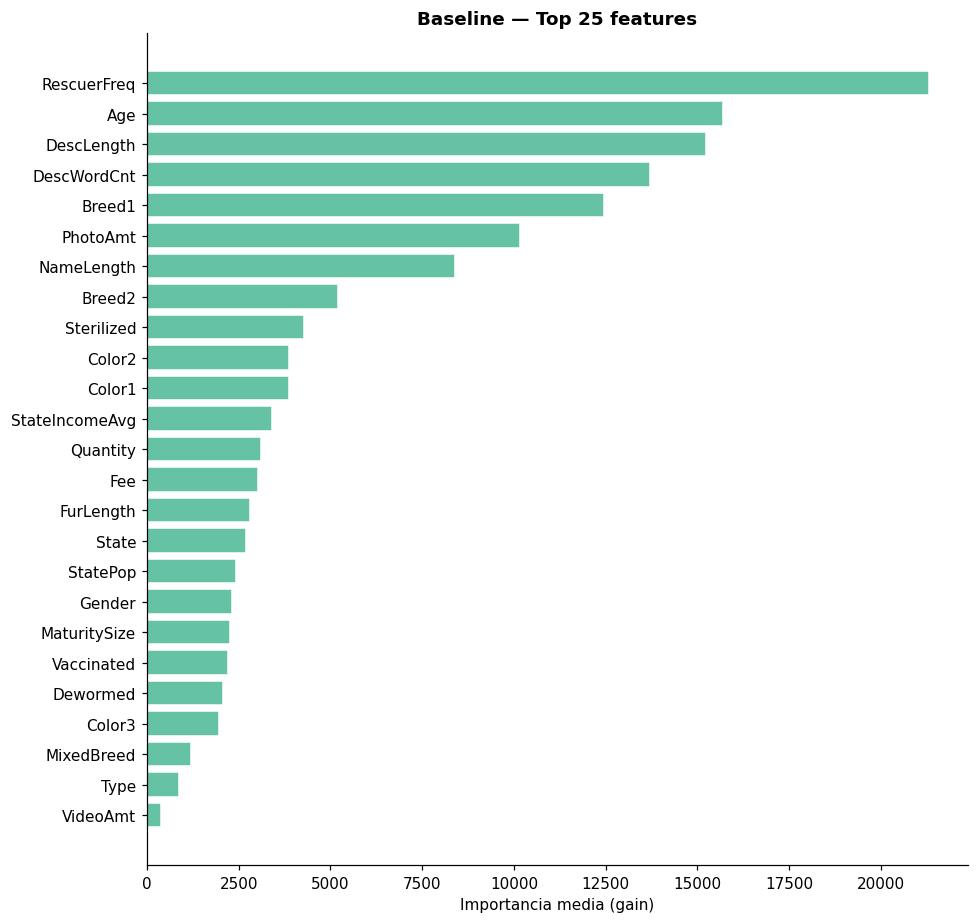

In [9]:
plot_results(y, result_baseline['oof_preds'], title='Baseline — LightGBM sin FE')
plot_importance(result_baseline['feat_imp'], top_n=25, title='Baseline — Top 25 features')

**Observaciones a registrar:**
- El QWK baseline establece el piso. Cualquier experimento que no lo supere descarta sus features.
- El modelo tiende a clasificar los registros con las categorías más altas (1, 2 y 4) en mayor medida. Esto explica que la métrica de Accuracy sea algo más alta que la de QWK: como la clase 4 es mayoritaria, clasificar como 4 a la mayoría de los registros aumentará los aciertos nominales, pero implica deficiencias para predecir las clases minoritarias. Por el contrario, la baja métrica F1 refleja las dificultades para identificar las clases minoritarias.
- La principal dificultad se observa en la clase 0: un recall de 0.05 indica que el modelo sólo identifica 1 de cada 20 registros con clase 0.
- Algunas de las variables más relevantes en el modelo baseline son aquellas derivadas del largo de la Descripción, la frecuencia de publicaciones del adoptante, la edad, el largo del nombre, la cantidad de fotos y la raza principal.

---
## 4. Feature Engineering iterativo

### Estrategia
Cada bloque de FE:
1. Define una familia de features nuevas
2. Las agrega al conjunto acumulado
3. Entrena y evalúa con `run_cv`
4. Registra el delta de QWK en `tracker`

Solo se mantienen las features que mejoran el QWK. Al final de cada bloque, la variable `CURRENT_FEATURES` refleja el mejor conjunto hasta el momento.

> **Regla anti-leakage:** cualquier transformación que use información del target (target encoding, estadísticas por grupo) se aplica **dentro del loop de folds** en `run_cv_with_te`.

In [10]:
# Estado acumulado de features
CURRENT_FEATURES = BASELINE_FEATURES.copy()
df_fe = df.copy()  # DataFrame que irá acumulando nuevas columnas

def delta(result_new, result_ref):
    d = result_new['qwk_mean'] - result_ref['qwk_mean']
    sign = '+' if d >= 0 else ''
    print(f'  ΔQWK vs. referencia: {sign}{d:.4f}')
    return d

print('FE iterativo listo.')

FE iterativo listo.


### 4.1 Transformaciones numéricas

- `log1p` de variables con alta skewness (`Fee`, `Age`, `PhotoAmt`)
- Flags de presencia (`has_*`), ya creadas en base
- Bins de edad y foto para capturar no-linealidades

In [11]:
df_fe.head(3)

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,IsFree,MixedBreed,MixedColor,IsGroup,NameLength,DescLength,DescWordCnt,RescuerFreq,StatePop,StateIncomeAvg
0,2,nibble,3,299,0,1,1,7,0,1,...,0,0,1,0,6.0,359.0,69,8,13296,7407
1,2,NaN,1,265,0,1,1,2,0,2,...,1,0,1,0,0.0,118.0,23,1,13985,2074
2,1,brisco,1,307,0,1,2,7,0,2,...,1,1,1,0,6.0,393.0,69,459,13296,7407


In [12]:
# ── Transformaciones de skewness ──────────────────────────────────────────────
df_fe['Age_log']     = np.log1p(df_fe['Age'])
df_fe['Fee_log']     = np.log1p(df_fe['Fee'])
df_fe['PhotoAmt_log']= np.log1p(df_fe['PhotoAmt'])
df_fe['Qty_log']     = np.log1p(df_fe['Quantity'])

# ── Bins de Age ───────────────────────────────────────────────────────────────
df_fe['AgeBin'] = pd.cut(
    df_fe['Age'],
    bins=[-1, 2, 6, 12, 24, 60, 9999],
    labels=[0, 1, 2, 3, 4, 5]  # ordinal numérico para LGBM
).astype(float)

# ── Bins de PhotoAmt ──────────────────────────────────────────────────────────
df_fe['PhotoBin'] = pd.cut(
    df_fe['PhotoAmt'].fillna(0),
    bins=[-1, 0, 2, 5, 100],
    labels=[0, 1, 2, 3]
).astype(float)

# ── Score de salud combinado ──────────────────────────────────────────────────
# Vaccinated/Dewormed/Sterilized: 1=Sí(bueno), 2=No, 3=No sabe
# Convertimos a 1=Sí, 0=otro para sumar
df_fe['VaccYes']  = (df_fe['Vaccinated']  == 1).astype(int)
df_fe['DewormYes']= (df_fe['Dewormed']    == 1).astype(int)
df_fe['SterYes']  = (df_fe['Sterilized']  == 1).astype(int)
df_fe['HealthScore'] = df_fe['VaccYes'] + df_fe['DewormYes'] + df_fe['SterYes']

NEW_NUM = ['Age_log','Fee_log','PhotoAmt_log','Qty_log',
           'AgeBin','PhotoBin','HealthScore']

CURRENT_FEATURES_41 = CURRENT_FEATURES + NEW_NUM
X_41 = df_fe[CURRENT_FEATURES_41]

print(f'Features nuevas (4.1): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_41)}')

print('\n' + '='*55)
print('EXPERIMENTO 1: + Transformaciones numéricas')
print('='*55)

result_41 = run_cv(X_41, y, BASELINE_PARAMS, experiment_name='01_num_transforms')
tracker.log(result_41)
delta(result_41, result_baseline)


Features nuevas (4.1): ['Age_log', 'Fee_log', 'PhotoAmt_log', 'Qty_log', 'AgeBin', 'PhotoBin', 'HealthScore']
Total features: 40

EXPERIMENTO 1: + Transformaciones numéricas
  Fold 1: QWK=0.3695  Acc=0.4368  F1=0.3556  (best iter=129)
  Fold 2: QWK=0.3875  Acc=0.4398  F1=0.3651  (best iter=109)
  Fold 3: QWK=0.4089  Acc=0.4431  F1=0.3434  (best iter=106)
  Fold 4: QWK=0.3791  Acc=0.4310  F1=0.3357  (best iter=83)
  Fold 5: QWK=0.3984  Acc=0.4546  F1=0.3637  (best iter=108)

  ► 01_num_transforms
    QWK  0.3887 ± 0.0139
    Acc  0.4411
    F1   0.3527
  ΔQWK vs. referencia: +0.0000


np.float64(1.3984926864551994e-05)

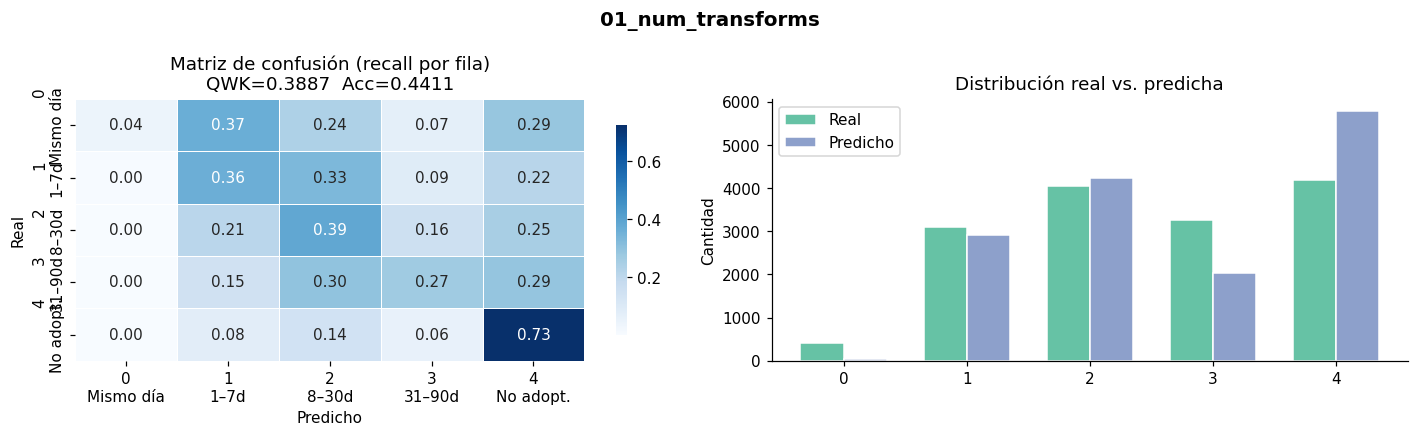

              precision    recall  f1-score   support

  0-MismoDía       0.40      0.04      0.08       410
  1-1ªSemana       0.38      0.36      0.37      3090
    2-1erMes       0.37      0.39      0.38      4037
 3-2do3erMes       0.43      0.27      0.33      3259
  4-NoAdopt.       0.53      0.73      0.61      4197

    accuracy                           0.44     14993
   macro avg       0.42      0.36      0.35     14993
weighted avg       0.43      0.44      0.42     14993



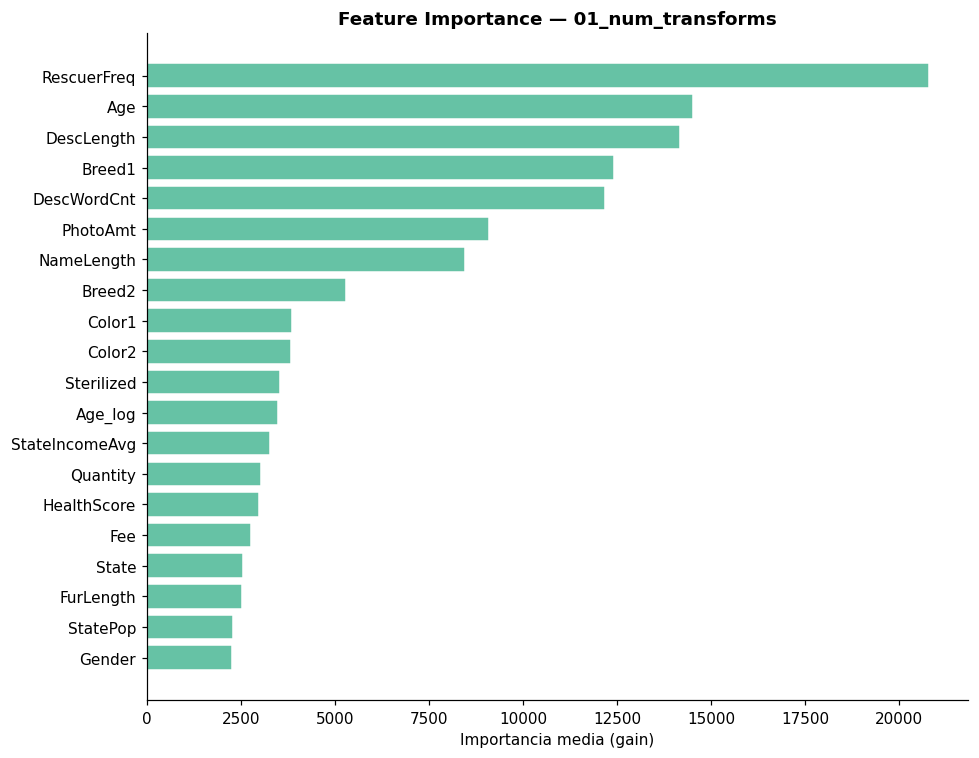

In [13]:
plot_results(y, result_41['oof_preds'], title='01_num_transforms')
plot_importance(result_41['feat_imp'], title='Feature Importance — 01_num_transforms')

In [14]:
NEW_NUM = ['HealthScore']

CURRENT_FEATURES_41 = CURRENT_FEATURES + NEW_NUM
X_41 = df_fe[CURRENT_FEATURES_41]

print(f'Features nuevas (4.1): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_41)}')

print('\n' + '='*55)
print('EXPERIMENTO 1: + Transformaciones numéricas')
print('='*55)

result_41 = run_cv(X_41, y, BASELINE_PARAMS, experiment_name='01_num_transforms')
tracker.log(result_41)
delta(result_41, result_baseline)

Features nuevas (4.1): ['HealthScore']
Total features: 34

EXPERIMENTO 1: + Transformaciones numéricas
  Fold 1: QWK=0.3723  Acc=0.4315  F1=0.3543  (best iter=100)
  Fold 2: QWK=0.3946  Acc=0.4441  F1=0.3784  (best iter=97)
  Fold 3: QWK=0.4048  Acc=0.4418  F1=0.3386  (best iter=84)
  Fold 4: QWK=0.3726  Acc=0.4340  F1=0.3436  (best iter=86)
  Fold 5: QWK=0.4008  Acc=0.4556  F1=0.3704  (best iter=124)

  ► 01_num_transforms
    QWK  0.3890 ± 0.0139
    Acc  0.4414
    F1   0.3571
  ΔQWK vs. referencia: +0.0004


np.float64(0.0003510078267078276)

In [15]:
# ¿Mejora? Actualizar CURRENT_FEATURES
if result_41['qwk_mean'] > result_baseline['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_41
    best_result = result_41
    print('✓ Features 4.1 incorporadas al conjunto acumulado.')
else:
    best_result = result_baseline
    print('✗ Features 4.1 no mejoran. Se descarta este bloque.')

✓ Features 4.1 incorporadas al conjunto acumulado.


 El aporte de las variables logísticas creadas es casi imperceptible. En el gráfico de Feature Importance se observa que todas se encuentran por debajo de las originales. 
Las variables 'bin' tampoco tienen aportes significativos frente al baseline. 
> No se incorporan al modelo

Por el contrario, la variable HealthScore, aunque bajo, muestra un poco más de valor y se incorpora al modelo.


### 4.2 Features de interacción

Interacciones relevantes identificadas en el EDA:
- `Type × Age`: gatos y perros tienen distintos perfiles de edad-adopción
- `Type × IsFree`: el efecto del precio varía por tipo
- `Age × IsFree`: cachorros gratuitos vs. adultos con costo
- `Fee × PhotoAmt`: publicaciones cuidadas tienden a ser mejores en todo

In [16]:
df_fe['Type_x_Age']    = df_fe['Type']   * df_fe['Age_log']
df_fe['Type_x_IsFree'] = df_fe['Type']   * df_fe['IsFree']
df_fe['Age_x_IsFree']  = df_fe['Age_log']* df_fe['IsFree']
df_fe['Fee_x_Photo']   = df_fe['Fee_log']* df_fe['PhotoAmt_log']
df_fe['Age_x_Photo']   = df_fe['Age_log']* df_fe['PhotoAmt_log']
df_fe['Health_x_Type'] = df_fe['Health'] * df_fe['Type']
df_fe['Type_x_Mixed']  = df_fe['Type']   * df_fe['MixedBreed']

NEW_INT = ['Type_x_Age',
           'Type_x_IsFree',
           'Age_x_IsFree',
           'Fee_x_Photo',
           'Age_x_Photo',
           'Health_x_Type',
           'Type_x_Mixed']

CURRENT_FEATURES_42 = CURRENT_FEATURES + NEW_INT
X_42 = df_fe[CURRENT_FEATURES_42]

print(f'Features nuevas (4.2): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_42)}')

print('\n' + '='*55)
print('EXPERIMENTO 2: + Interacciones')
print('='*55)

result_42 = run_cv(X_42, y, BASELINE_PARAMS, experiment_name='02_interactions')
tracker.log(result_42)
delta(result_42, best_result)


Features nuevas (4.2): ['Type_x_Age', 'Type_x_IsFree', 'Age_x_IsFree', 'Fee_x_Photo', 'Age_x_Photo', 'Health_x_Type', 'Type_x_Mixed']
Total features: 41

EXPERIMENTO 2: + Interacciones
  Fold 1: QWK=0.3748  Acc=0.4328  F1=0.3606  (best iter=101)
  Fold 2: QWK=0.4018  Acc=0.4418  F1=0.3709  (best iter=107)
  Fold 3: QWK=0.4042  Acc=0.4431  F1=0.3399  (best iter=96)
  Fold 4: QWK=0.3638  Acc=0.4330  F1=0.3385  (best iter=81)
  Fold 5: QWK=0.3913  Acc=0.4450  F1=0.3669  (best iter=94)

  ► 02_interactions
    QWK  0.3872 ± 0.0156
    Acc  0.4391
    F1   0.3554
  ΔQWK vs. referencia: -0.0018


np.float64(-0.0018401401229247716)

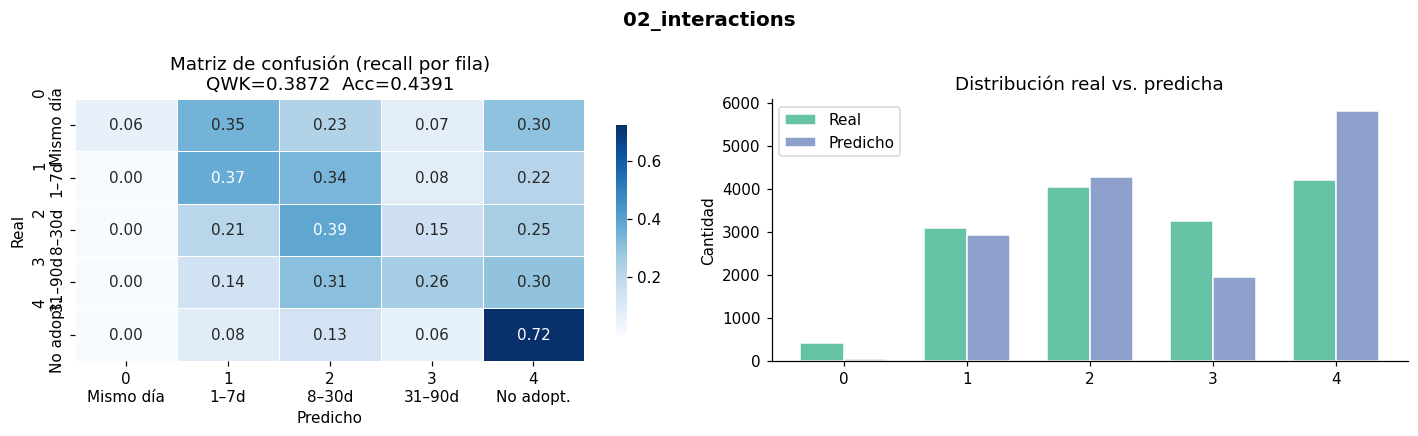

              precision    recall  f1-score   support

  0-MismoDía       0.52      0.06      0.10       410
  1-1ªSemana       0.39      0.37      0.38      3090
    2-1erMes       0.37      0.39      0.38      4037
 3-2do3erMes       0.43      0.26      0.32      3259
  4-NoAdopt.       0.52      0.72      0.61      4197

    accuracy                           0.44     14993
   macro avg       0.44      0.36      0.36     14993
weighted avg       0.43      0.44      0.42     14993



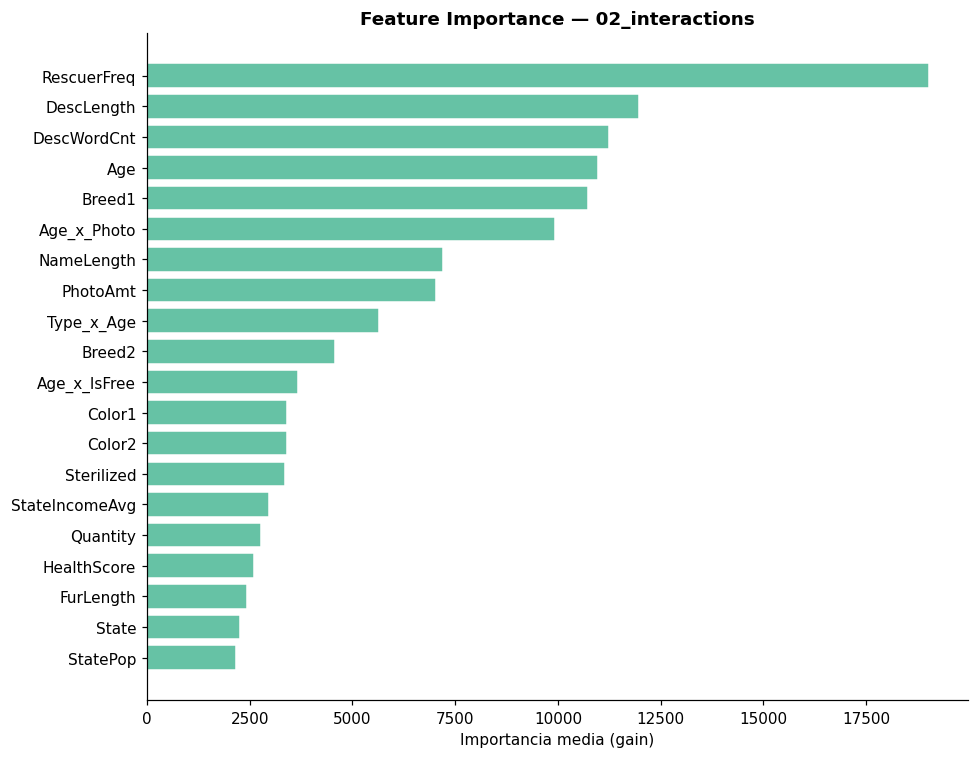

In [17]:
plot_results(y, result_42['oof_preds'], title='02_interactions')
plot_importance(result_42['feat_imp'], title='Feature Importance — 02_interactions')

In [18]:
if result_42['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_42
    best_result = result_42
    print('✓ Features 4.2 incorporadas.')
else:
    print('✗ Features 4.2 no mejoran. Se descarta.')

✗ Features 4.2 no mejoran. Se descarta.


Estas variables no están aportando valor al modelo. Se observa que, por ejemplo, las variables que utilizan Age como una de las interacciones (Age_x_IsFree o Type_x_Age) se encuentran por debajo de Age misma.
Esto puede estar relacionado con que los modelos basados en árboles ya tienen la capacidad de capturar interacciones entre variables.
> No se incorporan al modelo

### 4.3 Aggregations por RescuerID

Features agregadas que capturan el comportamiento histórico del rescatista: ¿publica muchos animales similares? ¿Cómo le fue en promedio? Esto puede capturar efectos de "estilo" de publicación que el modelo no puede aprender de otra forma.

In [19]:
# Agregaciones por RescuerID (sin usar target directamente — son estadísticas de features)
rescuer_agg = df_fe.groupby('RescuerID').agg(
    resc_mean_age    = ('Age',      'mean'),
    resc_mean_fee    = ('Fee',      'mean'),
    resc_mean_photos = ('PhotoAmt', 'mean'),
    resc_pct_free    = ('IsFree',   'mean'),
    resc_pct_dog     = ('Type',     lambda x: (x == 1).mean()),
    resc_n_breeds    = ('Breed1',   'nunique'),
).reset_index()

df_fe = df_fe.merge(rescuer_agg, on='RescuerID', how='left')

NEW_AGG = ['resc_mean_age','resc_mean_fee','resc_mean_photos',
           'resc_pct_free','resc_pct_dog','resc_n_breeds']

CURRENT_FEATURES_43 = CURRENT_FEATURES + NEW_AGG
X_43 = df_fe[CURRENT_FEATURES_43]

print(f'Features nuevas (4.3): {NEW_AGG}')
print(f'Total features: {len(CURRENT_FEATURES_43)}')

print('\n' + '='*55)
print('EXPERIMENTO 3: + Aggregations por rescatista')
print('='*55)

result_43 = run_cv(X_43, y, BASELINE_PARAMS, experiment_name='03_rescuer_agg')
tracker.log(result_43)
delta(result_43, best_result)

Features nuevas (4.3): ['resc_mean_age', 'resc_mean_fee', 'resc_mean_photos', 'resc_pct_free', 'resc_pct_dog', 'resc_n_breeds']
Total features: 40

EXPERIMENTO 3: + Aggregations por rescatista
  Fold 1: QWK=0.3978  Acc=0.4528  F1=0.3804  (best iter=121)
  Fold 2: QWK=0.4213  Acc=0.4652  F1=0.3904  (best iter=92)
  Fold 3: QWK=0.4150  Acc=0.4545  F1=0.3567  (best iter=102)
  Fold 4: QWK=0.4037  Acc=0.4556  F1=0.3574  (best iter=107)
  Fold 5: QWK=0.4188  Acc=0.4666  F1=0.3882  (best iter=102)

  ► 03_rescuer_agg
    QWK  0.4113 ± 0.0091
    Acc  0.4589
    F1   0.3746
  ΔQWK vs. referencia: +0.0223


np.float64(0.022309919985840976)

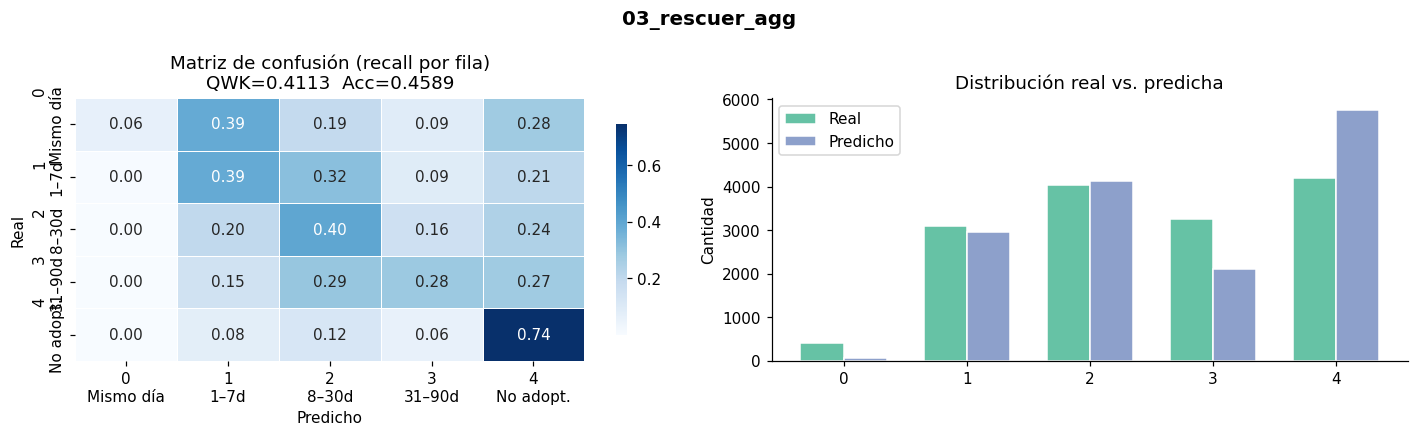

              precision    recall  f1-score   support

  0-MismoDía       0.49      0.06      0.11       410
  1-1ªSemana       0.40      0.39      0.39      3090
    2-1erMes       0.39      0.40      0.40      4037
 3-2do3erMes       0.44      0.28      0.34      3259
  4-NoAdopt.       0.54      0.74      0.63      4197

    accuracy                           0.46     14993
   macro avg       0.45      0.38      0.37     14993
weighted avg       0.45      0.46      0.44     14993



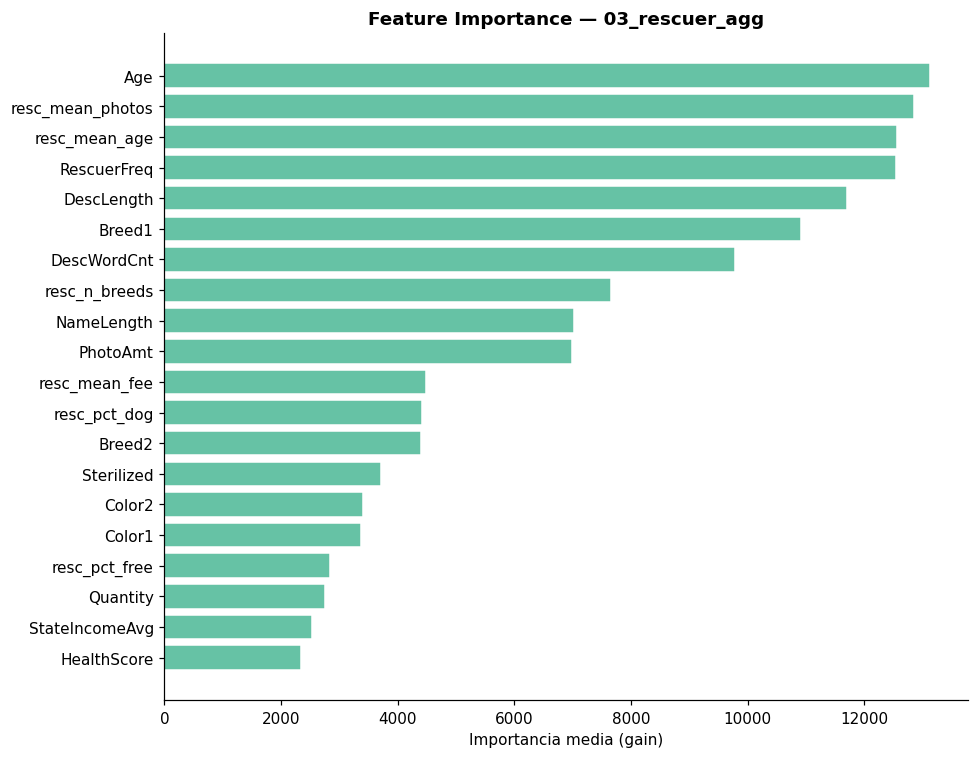

In [20]:
plot_results(y, result_43['oof_preds'], title='03_rescuer_agg')
plot_importance(result_43['feat_imp'], title='Feature Importance — 03_rescuer_agg')

In [21]:
if result_43['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_43
    best_result = result_43
    print('✓ Features 4.3 incorporadas.')
else:
    print('✗ Features 4.3 no mejoran. Se descarta.')

print(f'\nMejor conjunto hasta ahora: {best_result["name"]}')
print(f'QWK acumulado: {best_result["qwk_mean"]:.4f}')
print(f'N features: {len(CURRENT_FEATURES)}')

✓ Features 4.3 incorporadas.

Mejor conjunto hasta ahora: 03_rescuer_agg
QWK acumulado: 0.4113
N features: 40


### 4.4 Target Encoding con validación cruzada

Variables de alta cardinalidad (`Breed1`, `State`, `RescuerID`) se codifican con target encoding **dentro del fold** para evitar leakage. Se usa suavizado con la media global (Laplace smoothing) para manejar categorías poco frecuentes.

`RescuerID` es especialmente interesante: la varianza entre rescatistas observada en el EDA justifica este encoding.

In [22]:
def target_encode_cv(df_full, col, target_col, n_folds=N_FOLDS, smoothing=10):
    """
    Target encoding con CV para evitar leakage.
    Para cada fold, el encoding de validación se calcula SOLO con train.
    Retorna un array con el encoding OOF (out-of-fold).
    """
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    global_mean = df_full[target_col].mean()
    encoded = np.zeros(len(df_full))

    for tr_idx, val_idx in skf.split(df_full, df_full[target_col]):
        df_tr  = df_full.iloc[tr_idx]
        df_val = df_full.iloc[val_idx]

        stats = df_tr.groupby(col)[target_col].agg(['mean','count'])
        stats['smoothed'] = (
            (stats['mean'] * stats['count'] + global_mean * smoothing) /
            (stats['count'] + smoothing)
        )
        enc_map = stats['smoothed'].to_dict()
        encoded[val_idx] = df_val[col].map(enc_map).fillna(global_mean)

    return encoded


TE_COLS = ['Breed1', 'State', 'RescuerID']

for col in TE_COLS:
    new_col = f'{col}_te'
    df_fe[new_col] = target_encode_cv(df_fe, col, TARGET)
    print(f'  {new_col}: min={df_fe[new_col].min():.2f}  '
          f'max={df_fe[new_col].max():.2f}  '
          f'mean={df_fe[new_col].mean():.2f}')

NEW_TE = [f'{c}_te' for c in TE_COLS]
CURRENT_FEATURES_44 = CURRENT_FEATURES + NEW_TE
X_44 = df_fe[CURRENT_FEATURES_44]

print(f'\nFeatures nuevas (4.4): {NEW_TE}')
print(f'Total features: {len(CURRENT_FEATURES_44)}')

print('\n' + '='*55)
print('EXPERIMENTO 4: + Target Encoding (Breed1, State, RescuerID)')
print('='*55)

result_44 = run_cv(X_44, y, BASELINE_PARAMS, experiment_name='04_target_encoding')
tracker.log(result_44)
delta(result_44, best_result)

  Breed1_te: min=1.82  max=2.94  mean=2.52
  State_te: min=2.26  max=3.06  mean=2.51
  RescuerID_te: min=1.58  max=3.54  mean=2.48

Features nuevas (4.4): ['Breed1_te', 'State_te', 'RescuerID_te']
Total features: 43

EXPERIMENTO 4: + Target Encoding (Breed1, State, RescuerID)
  Fold 1: QWK=0.4189  Acc=0.4645  F1=0.3948  (best iter=79)
  Fold 2: QWK=0.4539  Acc=0.4735  F1=0.3926  (best iter=95)
  Fold 3: QWK=0.4473  Acc=0.4655  F1=0.3769  (best iter=97)
  Fold 4: QWK=0.4514  Acc=0.4807  F1=0.3772  (best iter=66)
  Fold 5: QWK=0.4507  Acc=0.4823  F1=0.3990  (best iter=80)

  ► 04_target_encoding
    QWK  0.4445 ± 0.0130
    Acc  0.4733
    F1   0.3881
  ΔQWK vs. referencia: +0.0331


np.float64(0.03312225312578093)

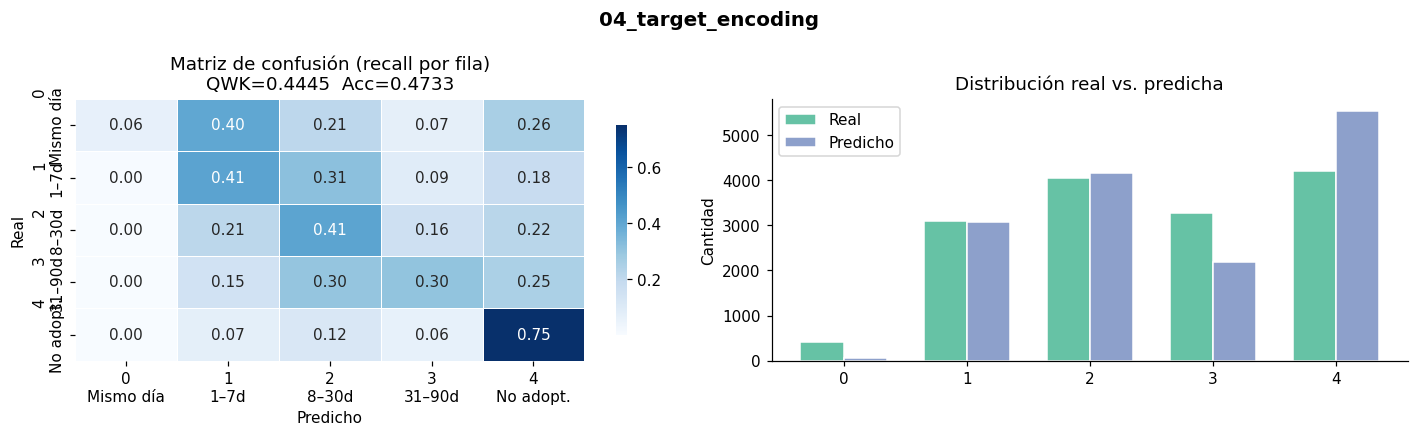

              precision    recall  f1-score   support

  0-MismoDía       0.49      0.06      0.11       410
  1-1ªSemana       0.41      0.41      0.41      3090
    2-1erMes       0.40      0.41      0.40      4037
 3-2do3erMes       0.46      0.30      0.36      3259
  4-NoAdopt.       0.57      0.75      0.65      4197

    accuracy                           0.47     14993
   macro avg       0.47      0.39      0.39     14993
weighted avg       0.46      0.47      0.46     14993



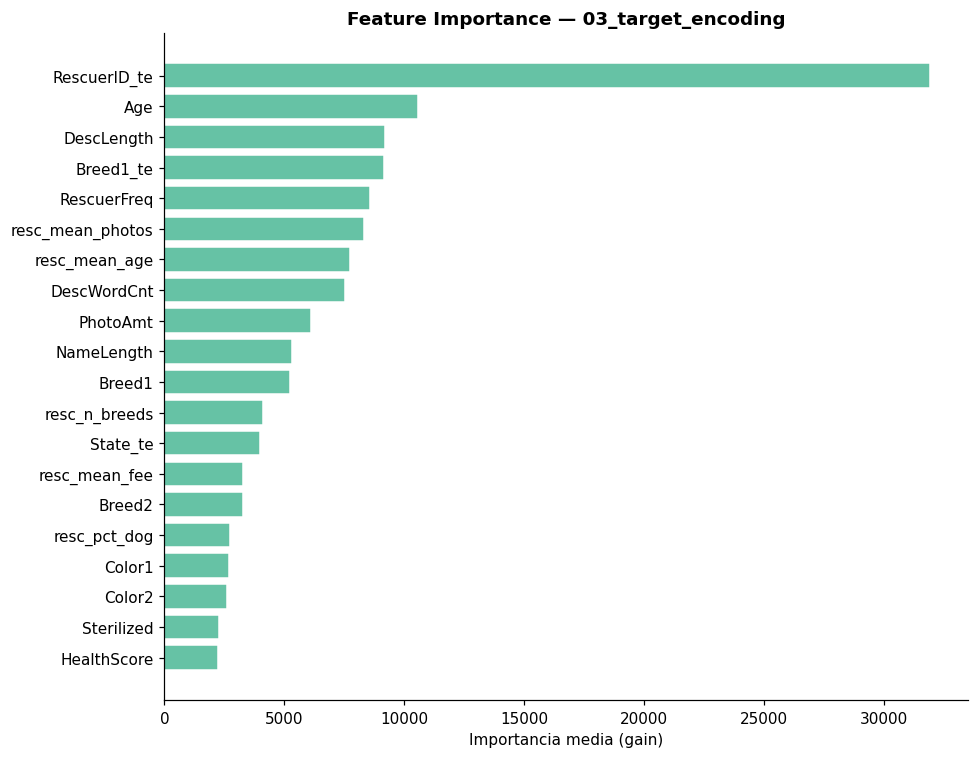

In [23]:
plot_results(y, result_44['oof_preds'], title='04_target_encoding')
plot_importance(result_44['feat_imp'], title='Feature Importance — 03_target_encoding')

Se sospecha que estas variables puedan tener Leakage presente. Principalmente se analiza el efecto de la variable de RescuerID_te, ya que si se cuenta con rescatistas con pocas publicaciones, puede suceder que el encoding de un registro se calcule usando el target de ese mismo registro.
Para esto, se evaluarán modelos entrenados con distintos valores de smoothing. Aumentar el valor de smoothing llevará a los rescatistas con pocas publicaciones a valores más cercanos a la media. Si al aumentar el smoothing cae la métrica de QWK, significa que los rescatistas con pocas publicaciones generan Leakage en esta variable. Si el QWK es estable entre distintos niveles de smoothing, se considerará que los rescatistas con muchas publicaciones tendrán una gran capacidad explicativa de la probabilidad de adopción, probablemente dado a su experiencia.


In [24]:
for smooth in [10, 20, 50, 100]:
    for col in TE_COLS:
        df_fe[f'{col}_te'] = target_encode_cv(
            df_fe, col, TARGET, smoothing=smooth
        )
    # Reconstruir X en cada iteración
    X_test = df_fe[CURRENT_FEATURES_44]  # ← esto faltaba
    result = run_cv(X_test, y, BASELINE_PARAMS, 
                    experiment_name=f'te_smooth_{smooth}')
    print(f'smoothing={smooth}  QWK={result["qwk_mean"]:.4f}')

  Fold 1: QWK=0.4189  Acc=0.4645  F1=0.3948  (best iter=79)
  Fold 2: QWK=0.4539  Acc=0.4735  F1=0.3926  (best iter=95)
  Fold 3: QWK=0.4473  Acc=0.4655  F1=0.3769  (best iter=97)
  Fold 4: QWK=0.4514  Acc=0.4807  F1=0.3772  (best iter=66)
  Fold 5: QWK=0.4507  Acc=0.4823  F1=0.3990  (best iter=80)

  ► te_smooth_10
    QWK  0.4445 ± 0.0130
    Acc  0.4733
    F1   0.3881
smoothing=10  QWK=0.4445
  Fold 1: QWK=0.4208  Acc=0.4622  F1=0.3834  (best iter=82)
  Fold 2: QWK=0.4650  Acc=0.4748  F1=0.3849  (best iter=86)
  Fold 3: QWK=0.4500  Acc=0.4655  F1=0.3726  (best iter=100)
  Fold 4: QWK=0.4519  Acc=0.4790  F1=0.3882  (best iter=81)
  Fold 5: QWK=0.4516  Acc=0.4777  F1=0.3958  (best iter=113)

  ► te_smooth_20
    QWK  0.4478 ± 0.0146
    Acc  0.4718
    F1   0.3850
smoothing=20  QWK=0.4478
  Fold 1: QWK=0.4196  Acc=0.4652  F1=0.3860  (best iter=92)
  Fold 2: QWK=0.4763  Acc=0.4835  F1=0.4104  (best iter=122)
  Fold 3: QWK=0.4531  Acc=0.4652  F1=0.3779  (best iter=97)
  Fold 4: QWK=0.4

Las métricas son estables, esto indica que la variable no es riesgosa.
Se utilizará el valor de smoothing de 50 ya que presenta valores de QWK muy similares a la variable generada con smoothing de 10, con poco desvío estándar entre los folds. Esto dará más confianza sobre la necesidad de evitar el Leakage.

In [25]:
TE_COLS = ['Breed1', 'State', 'RescuerID']

for col in TE_COLS:
    new_col = f'{col}_te'
    df_fe[new_col] = target_encode_cv(df_fe, col, TARGET, smoothing=50)
    print(f'  {new_col}: min={df_fe[new_col].min():.2f}  '
          f'max={df_fe[new_col].max():.2f}  '
          f'mean={df_fe[new_col].mean():.2f}')

NEW_TE = [f'{c}_te' for c in TE_COLS]
CURRENT_FEATURES_44 = CURRENT_FEATURES + NEW_TE
X_43 = df_fe[CURRENT_FEATURES_44]

print(f'\nFeatures nuevas (4.4): {NEW_TE}')
print(f'Total features: {len(CURRENT_FEATURES_44)}')

print('\n' + '='*55)
print('EXPERIMENTO 4: + Target Encoding (Breed1, State, RescuerID)')
print('='*55)

result_44 = run_cv(X_44, y, BASELINE_PARAMS, experiment_name='03_target_encoding')
tracker.log(result_44)
delta(result_44, best_result)

  Breed1_te: min=2.03  max=2.75  mean=2.54
  State_te: min=2.35  max=2.92  mean=2.51
  RescuerID_te: min=2.03  max=3.04  mean=2.50

Features nuevas (4.4): ['Breed1_te', 'State_te', 'RescuerID_te']
Total features: 43

EXPERIMENTO 4: + Target Encoding (Breed1, State, RescuerID)
  Fold 1: QWK=0.4189  Acc=0.4645  F1=0.3948  (best iter=79)
  Fold 2: QWK=0.4539  Acc=0.4735  F1=0.3926  (best iter=95)
  Fold 3: QWK=0.4473  Acc=0.4655  F1=0.3769  (best iter=97)
  Fold 4: QWK=0.4514  Acc=0.4807  F1=0.3772  (best iter=66)
  Fold 5: QWK=0.4507  Acc=0.4823  F1=0.3990  (best iter=80)

  ► 03_target_encoding
    QWK  0.4445 ± 0.0130
    Acc  0.4733
    F1   0.3881
  ΔQWK vs. referencia: +0.0331


np.float64(0.03312225312578093)

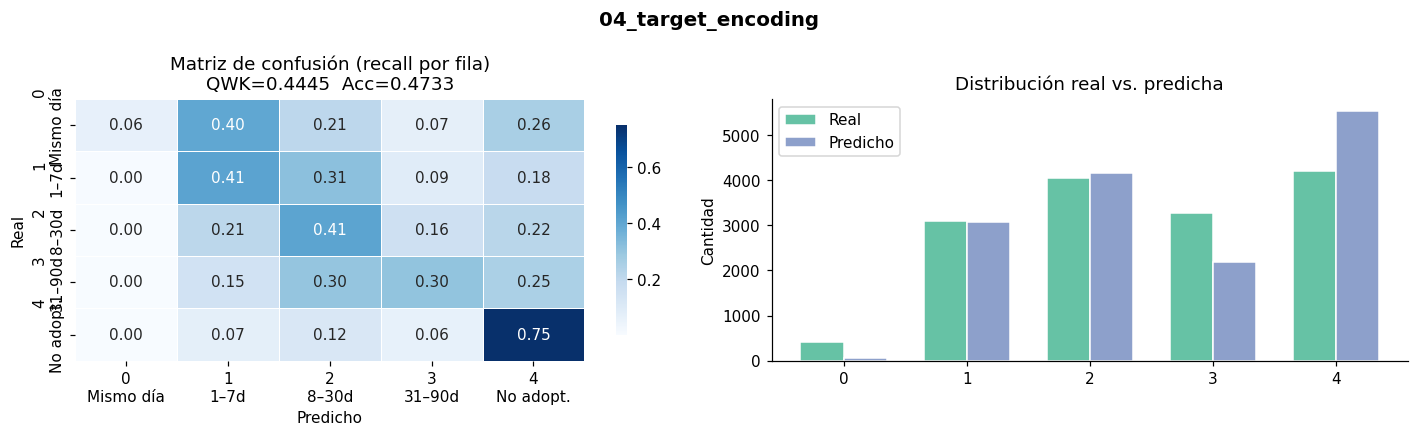

              precision    recall  f1-score   support

  0-MismoDía       0.49      0.06      0.11       410
  1-1ªSemana       0.41      0.41      0.41      3090
    2-1erMes       0.40      0.41      0.40      4037
 3-2do3erMes       0.46      0.30      0.36      3259
  4-NoAdopt.       0.57      0.75      0.65      4197

    accuracy                           0.47     14993
   macro avg       0.47      0.39      0.39     14993
weighted avg       0.46      0.47      0.46     14993



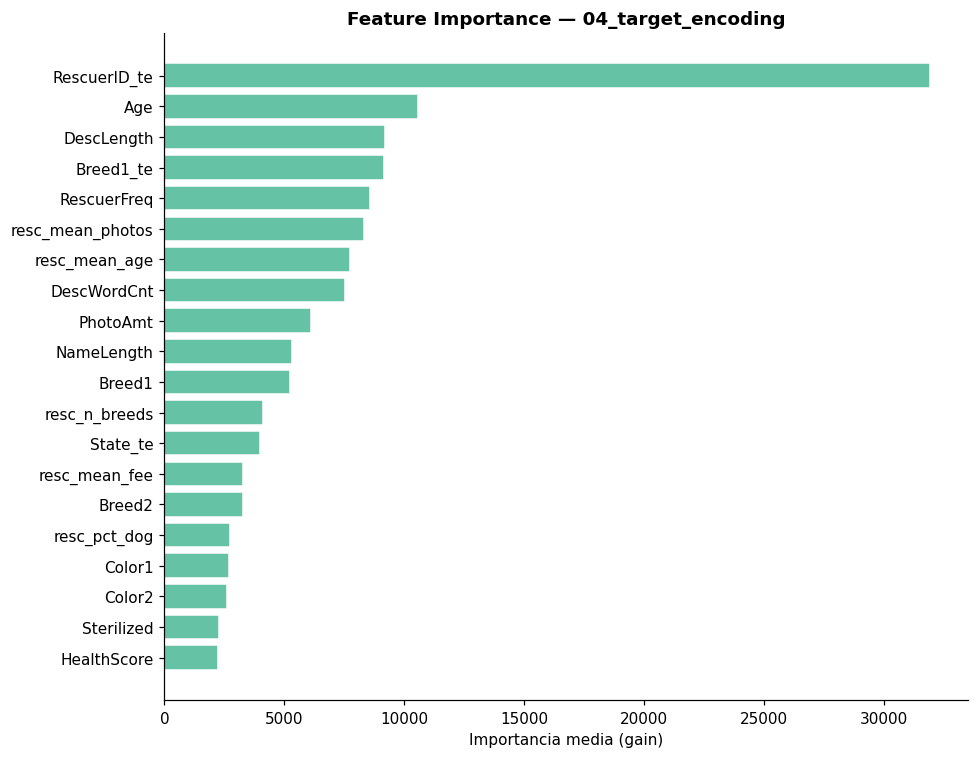

In [26]:
plot_results(y, result_44['oof_preds'], title='04_target_encoding')
plot_importance(result_44['feat_imp'], title='Feature Importance — 04_target_encoding')

In [27]:
if result_44['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_44
    best_result = result_44
    print('✓ Features 4.4 incorporadas.')
else:
    print('✗ Features 4.4 no mejoran. Se descarta.')

✓ Features 4.4 incorporadas.


### 4.5 Frequency Encoding

Alternativa al target encoding para variables de alta cardinalidad: reemplazar cada categoría por su frecuencia absoluta en el dataset. No tiene riesgo de leakage (no usa el target), pero captura si una raza/estado es común o raro, lo cual puede ser informativo para el modelo.

In [28]:
FE_COLS = ['Breed1', 'Breed2', 'State', 'Color1']

for col in FE_COLS:
    freq = df_fe[col].value_counts()
    df_fe[f'{col}_freq'] = df_fe[col].map(freq).fillna(0)

NEW_FREQ = [f'{c}_freq' for c in FE_COLS]
CURRENT_FEATURES_45 = CURRENT_FEATURES + NEW_FREQ
X_45 = df_fe[CURRENT_FEATURES_45]

print(f'Features nuevas (4.5): {NEW_FREQ}')
print(f'Total features: {len(CURRENT_FEATURES_44)}')

print('\n' + '='*55)
print('EXPERIMENTO 5: + Frequency Encoding')
print('='*55)

result_45 = run_cv(X_45, y, BASELINE_PARAMS, experiment_name='05_freq_encoding')
tracker.log(result_45)
delta(result_45, best_result)

Features nuevas (4.5): ['Breed1_freq', 'Breed2_freq', 'State_freq', 'Color1_freq']
Total features: 43

EXPERIMENTO 5: + Frequency Encoding
  Fold 1: QWK=0.4282  Acc=0.4588  F1=0.3790  (best iter=105)
  Fold 2: QWK=0.4719  Acc=0.4808  F1=0.4044  (best iter=83)
  Fold 3: QWK=0.4518  Acc=0.4678  F1=0.3821  (best iter=95)
  Fold 4: QWK=0.4616  Acc=0.4767  F1=0.3809  (best iter=66)
  Fold 5: QWK=0.4546  Acc=0.4803  F1=0.3932  (best iter=105)

  ► 05_freq_encoding
    QWK  0.4536 ± 0.0145
    Acc  0.4729
    F1   0.3879
  ΔQWK vs. referencia: +0.0092


np.float64(0.009179253358724382)

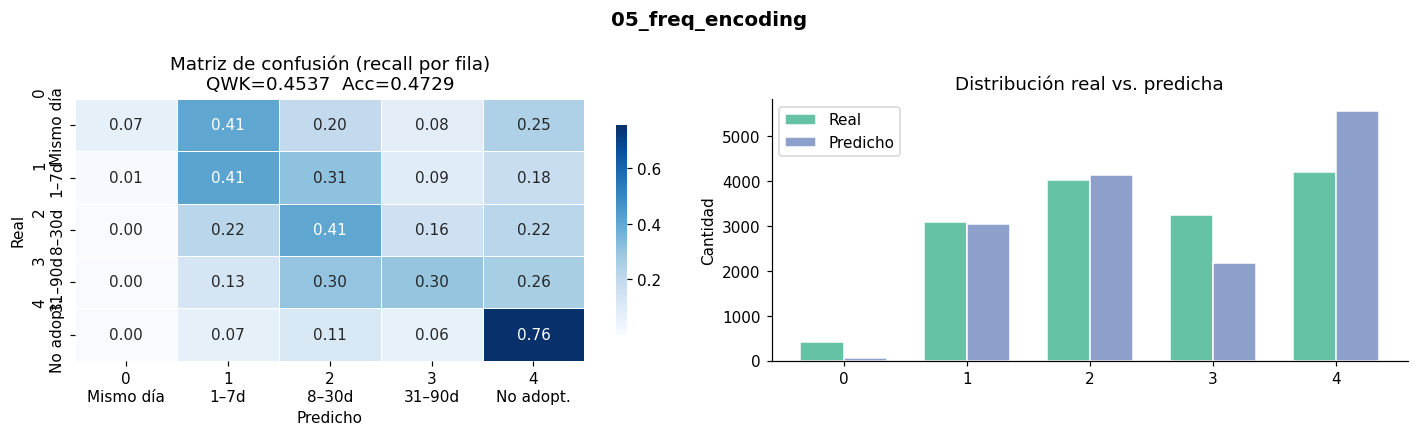

              precision    recall  f1-score   support

  0-MismoDía       0.44      0.07      0.11       410
  1-1ªSemana       0.42      0.41      0.42      3090
    2-1erMes       0.39      0.41      0.40      4037
 3-2do3erMes       0.45      0.30      0.36      3259
  4-NoAdopt.       0.57      0.76      0.65      4197

    accuracy                           0.47     14993
   macro avg       0.45      0.39      0.39     14993
weighted avg       0.46      0.47      0.46     14993



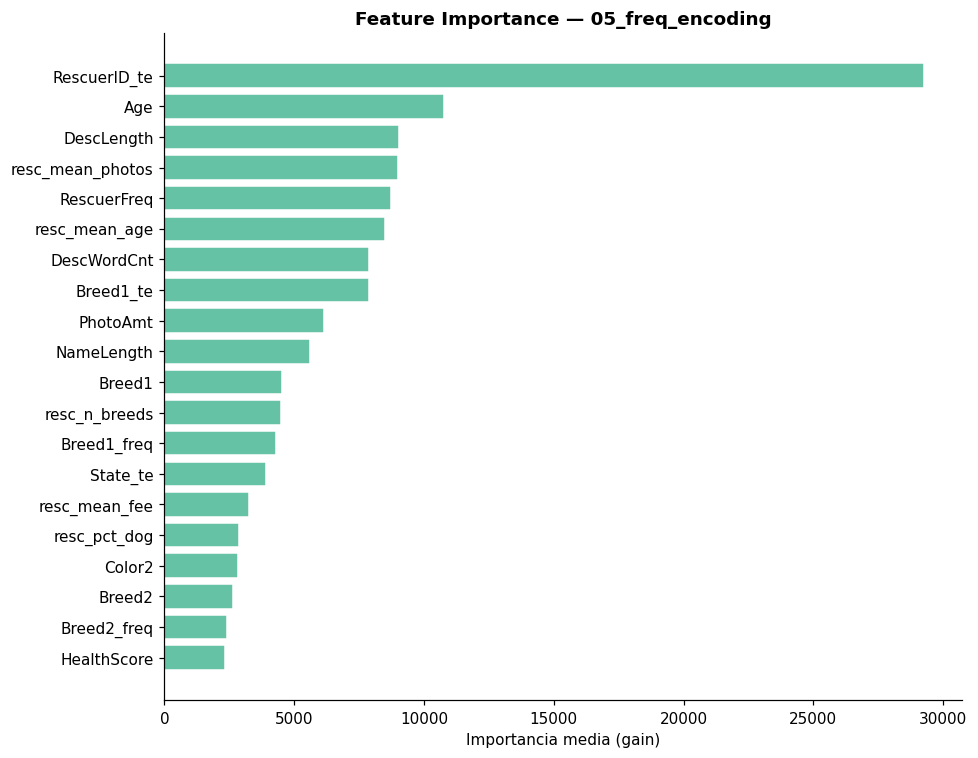

In [29]:
plot_results(y, result_45['oof_preds'], title='05_freq_encoding')
plot_importance(result_45['feat_imp'], title='Feature Importance — 05_freq_encoding')

In [30]:
if result_45['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_45
    best_result = result_45
    print('✓ Features 4.5 incorporadas.')
else:
    print('✗ Features 4.5 no mejoran. Se descarta.')

✓ Features 4.5 incorporadas.


No se observan mejorías con estas nuevas variables.

### 4.6 Features de texto — TF-IDF + SVD (LSA)

Se vectoriza `Description` con TF-IDF y luego se reduce con SVD (Latent Semantic Analysis) a 20 dimensiones. Estas representan los "temas" principales de las descripciones y pueden capturar señales que las features tabulares no tienen.

El TF-IDF se ajusta **solo sobre el conjunto de entrenamiento** de cada fold (no hay leakage porque no usa el target), pero para simplificar el notebook lo ajustamos sobre el dataset completo, lo cual es una simplificación aceptable dado que no involucra el target.

In [31]:
N_SVD_COMPONENTS = 15

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    strip_accents='unicode',
    sublinear_tf=True
)

svd = TruncatedSVD(n_components=N_SVD_COMPONENTS, random_state=SEED)

desc_text = df_fe['Description'].fillna('').values
tfidf_matrix = tfidf.fit_transform(desc_text)
svd_matrix   = svd.fit_transform(tfidf_matrix)

svd_cols = [f'desc_svd_{i}' for i in range(N_SVD_COMPONENTS)]
df_svd = pd.DataFrame(svd_matrix, columns=svd_cols, index=df_fe.index)
df_fe  = pd.concat([df_fe, df_svd], axis=1)

print(f'Varianza explicada por SVD: {svd.explained_variance_ratio_.sum():.3f}')
print(f'Columnas SVD generadas: {svd_cols[:5]}...')

CURRENT_FEATURES_46 = CURRENT_FEATURES + svd_cols
X_46 = df_fe[CURRENT_FEATURES_46]

print(f'\nTotal features: {len(CURRENT_FEATURES_46)}')

print('\n' + '='*55)
print('EXPERIMENTO 6: + TF-IDF/SVD sobre Description')
print('='*55)

result_46 = run_cv(X_46, y, BASELINE_PARAMS, experiment_name='06_text_svd')
tracker.log(result_46)
delta(result_46, best_result)

Varianza explicada por SVD: 0.085
Columnas SVD generadas: ['desc_svd_0', 'desc_svd_1', 'desc_svd_2', 'desc_svd_3', 'desc_svd_4']...

Total features: 62

EXPERIMENTO 6: + TF-IDF/SVD sobre Description
  Fold 1: QWK=0.4253  Acc=0.4682  F1=0.3807  (best iter=83)
  Fold 2: QWK=0.4680  Acc=0.4708  F1=0.3838  (best iter=88)
  Fold 3: QWK=0.4457  Acc=0.4692  F1=0.3746  (best iter=105)
  Fold 4: QWK=0.4567  Acc=0.4750  F1=0.3759  (best iter=74)
  Fold 5: QWK=0.4428  Acc=0.4803  F1=0.3914  (best iter=96)

  ► 06_text_svd
    QWK  0.4477 ± 0.0143
    Acc  0.4727
    F1   0.3813
  ΔQWK vs. referencia: -0.0059


np.float64(-0.005946154898048062)

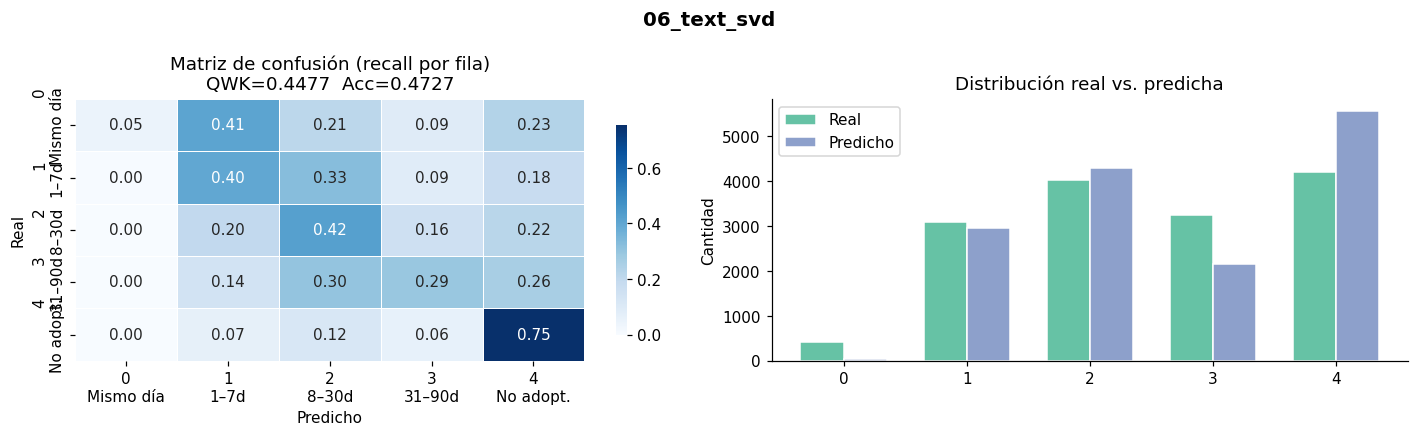

              precision    recall  f1-score   support

  0-MismoDía       0.61      0.05      0.09       410
  1-1ªSemana       0.42      0.40      0.41      3090
    2-1erMes       0.40      0.42      0.41      4037
 3-2do3erMes       0.44      0.29      0.35      3259
  4-NoAdopt.       0.57      0.75      0.65      4197

    accuracy                           0.47     14993
   macro avg       0.49      0.38      0.38     14993
weighted avg       0.47      0.47      0.46     14993



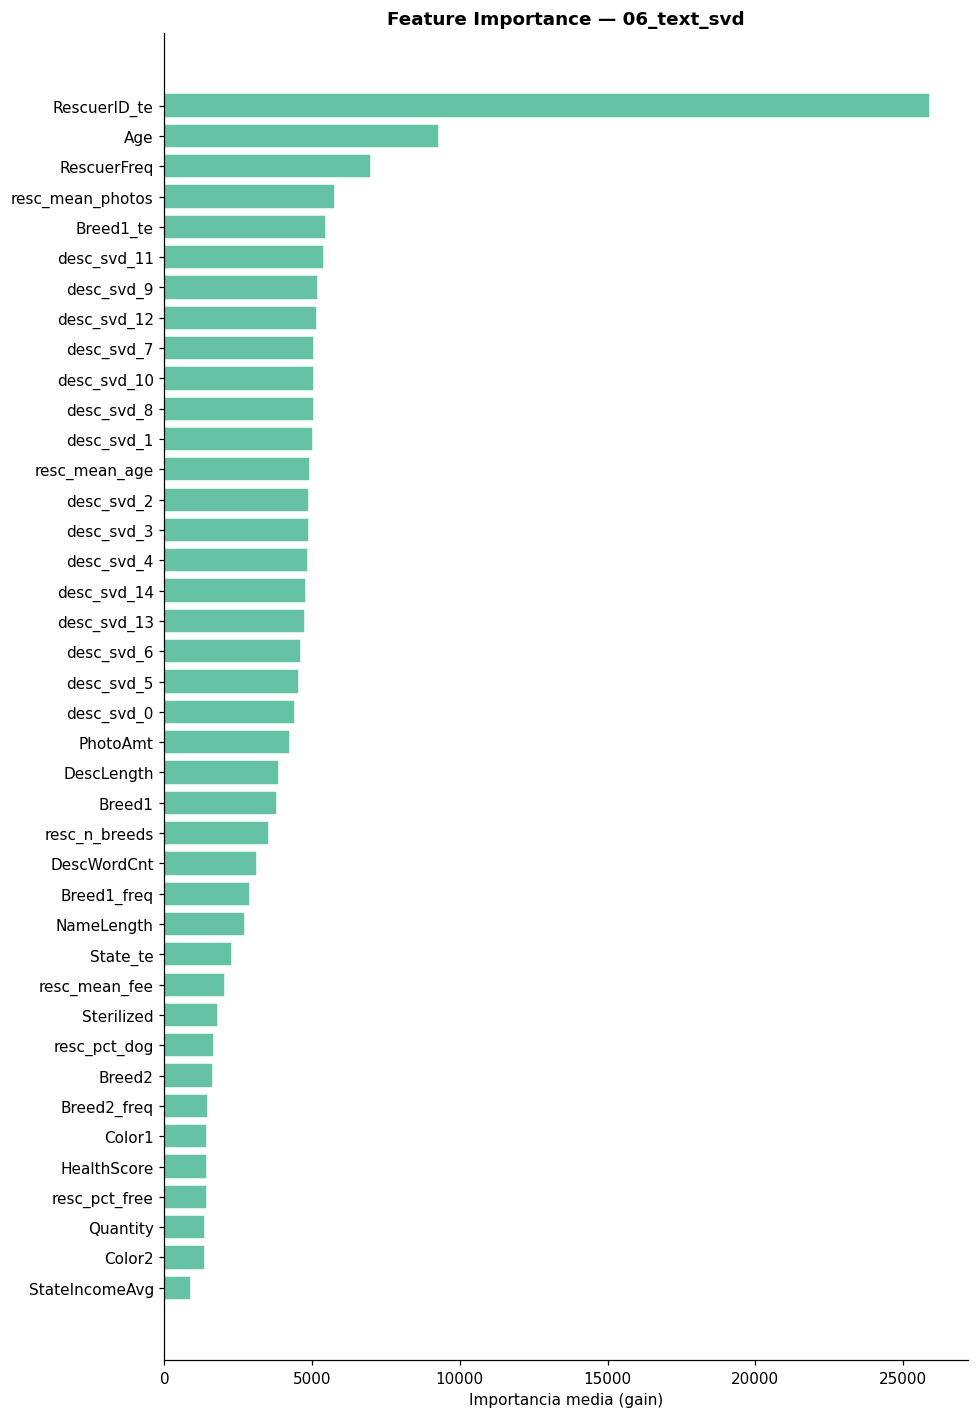

In [32]:
plot_results(y, result_46['oof_preds'], title='06_text_svd')
plot_importance(result_46['feat_imp'], title='Feature Importance — 06_text_svd', top_n = 40)

In [33]:
# Ver cuánta varianza explican los componentes
print(svd.explained_variance_ratio_)
# Si los últimos componentes tienen varianza < 0.01
# son ruido y se pueden descartar

# Ver correlación de SVD con variables existentes
svd_df = df_fe[svd_cols]
corr_with_type = svd_df.corrwith(df_fe['Type'])
print(corr_with_type.abs().sort_values(ascending=False))

[0.00792299 0.01165517 0.00777079 0.00670641 0.00597083 0.00555999
 0.00539823 0.00497075 0.0048052  0.00441348 0.00428071 0.00423349
 0.00374926 0.00371679 0.00349806]
desc_svd_9     0.373155
desc_svd_6     0.301703
desc_svd_4     0.223658
desc_svd_1     0.198144
desc_svd_10    0.178278
desc_svd_14    0.144563
desc_svd_11    0.137697
desc_svd_13    0.121382
desc_svd_8     0.092233
desc_svd_3     0.090557
desc_svd_5     0.079509
desc_svd_7     0.074018
desc_svd_2     0.056888
desc_svd_0     0.032201
desc_svd_12    0.007576
dtype: float64


In [34]:
if result_46['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_46
    best_result = result_46
    print('✓ Features 4.6 incorporadas.')
else:
    print('✗ Features 4.6 no mejoran. Se descarta.')

✗ Features 4.6 no mejoran. Se descarta.


Aunque desde el punto de vista del Feature Importance estas variables parecen tener peso, no aportan valor real predictivo: el QWK no mejora. Esto puede tener que ver con el idioma de las descripciones: aquellas en idiomas distintos al inglés pueden generar vectores iguales a 0, aportando ruido.
Se evaluará si el idioma tiene sesgos en alguna clase o si la distribución es uniforme:

In [35]:
!pip install langdetect
# Ver qué proporción de descripciones no están en inglés
from langdetect import detect

def safe_detect(text):
    try:
        return detect(str(text))
    except:
        return 'unknown'

df_fe['desc_lang'] = df_fe['Description'].fillna('').apply(safe_detect)
print(df_fe['desc_lang'].value_counts(normalize=True))

df_fe['is_english'] = (df_fe['desc_lang'] == 'en').astype(int)
print(df_fe.groupby(TARGET)['is_english'].mean())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=7b6eb36044a1cc3f40c1606bc116e8d2445888776bd6ee4becf3b0b2d3b47cfb
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
desc_lang
en         0.919296
unknown    0.032882
id         0.031014
de         0.003402
zh-cn      0.002134
no         0.001334
ro         0.000934
af         0.000867
tl         0.000800
fr         0.000734
da         0.000667
es         0.000600
so         0.000600
fi         0.000534
ko         0.000467
ca         0.000467
cy         0.000467
nl         0.000467
zh-tw      0.000333
sl         0.000333
hr         0.000267
sv         0.000267
sk         0.000267
it         0.000200
et         0.000200
vi         0.000133
tr         0.000133
sw         0.000067
pt

El 90% de las publicaciones están en inglés. Además, la distribución es uniforme. Se evaluará incorporar una variable tipo flag que indique si la descripción está en inglés o no.

In [36]:
# ── Flag de idioma ─────────────────────────────────────────────────────────────
df_fe['desc_is_english'] = (df_fe['desc_lang'] == 'en').astype(int)

NEW_LANG = ['desc_is_english']
CURRENT_FEATURES_46b = CURRENT_FEATURES + NEW_LANG
X_46b = df_fe[CURRENT_FEATURES_46b]

print(f'Features nuevas (4.6b): {NEW_LANG}')
print(f'Total features: {len(CURRENT_FEATURES_46b)}')
print('\n' + '='*55)
print('EXPERIMENTO 6b: + Flag idioma descripción (inglés s/n)')
print('='*55)
result_46b = run_cv(X_46b, y, BASELINE_PARAMS, experiment_name='06b_lang_flag')
tracker.log(result_46b)
delta(result_46b, best_result)

Features nuevas (4.6b): ['desc_is_english']
Total features: 48

EXPERIMENTO 6b: + Flag idioma descripción (inglés s/n)
  Fold 1: QWK=0.4296  Acc=0.4608  F1=0.3876  (best iter=102)
  Fold 2: QWK=0.4601  Acc=0.4732  F1=0.4021  (best iter=90)
  Fold 3: QWK=0.4525  Acc=0.4685  F1=0.3772  (best iter=78)
  Fold 4: QWK=0.4517  Acc=0.4820  F1=0.3824  (best iter=86)
  Fold 5: QWK=0.4549  Acc=0.4753  F1=0.3921  (best iter=100)

  ► 06b_lang_flag
    QWK  0.4498 ± 0.0105
    Acc  0.4720
    F1   0.3883
  ΔQWK vs. referencia: -0.0039


np.float64(-0.0038740148268372465)

In [37]:
if result_46b['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_46b
    best_result = result_46b
    print('✓ Features 4.6b incorporadas.')
else:
    print('✗ Features 4.6b no mejoran. Se descarta.')

✗ Features 4.6b no mejoran. Se descarta.


Esto tampoco aporta información relevante.

### 4.7 Features de texto — palabras clave y estadísticas

Complemento del SVD: features directamente interpretables sobre el texto de la descripción.

In [38]:
desc_lower = df_fe['Description'].fillna('').str.lower()

# Palabras clave
kw_pos = ['playful','friendly','loves','gentle','sweet','healthy',
           'vaccinated','trained','house','good']
kw_urg = ['urgent','please','help','desperate','danger',
           'euthanasia','last','deadline','dying','kill']

df_fe['kw_positive']  = desc_lower.apply(lambda x: sum(k in x for k in kw_pos))
df_fe['kw_urgent']    = desc_lower.apply(lambda x: sum(k in x for k in kw_urg))
df_fe['kw_pos_flag']  = (df_fe['kw_positive'] > 0).astype(int)
df_fe['kw_urg_flag']  = (df_fe['kw_urgent']   > 0).astype(int)

# Estadísticas de texto
df_fe['desc_avg_word_len'] = desc_lower.apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.strip() else 0
)
df_fe['desc_exclamations'] = df_fe['Description'].fillna('').str.count('!')
df_fe['desc_questions']    = df_fe['Description'].fillna('').str.count('\?')
df_fe['desc_sentences']    = df_fe['Description'].fillna('').str.count(r'[.!?]')

NEW_TEXT = ['kw_positive','kw_urgent','kw_pos_flag','kw_urg_flag',
            'desc_avg_word_len','desc_exclamations','desc_questions','desc_sentences']

CURRENT_FEATURES_47 = CURRENT_FEATURES + NEW_TEXT
X_47 = df_fe[CURRENT_FEATURES_47]

print(f'Features nuevas (4.7): {NEW_TEXT}')
print(f'Total features: {len(CURRENT_FEATURES_47)}')

print('\n' + '='*55)
print('EXPERIMENTO 7: + Features de texto (KW + stats)')
print('='*55)

result_47 = run_cv(X_47, y, BASELINE_PARAMS, experiment_name='07_text_features')
tracker.log(result_47)
delta(result_47, best_result)

Features nuevas (4.7): ['kw_positive', 'kw_urgent', 'kw_pos_flag', 'kw_urg_flag', 'desc_avg_word_len', 'desc_exclamations', 'desc_questions', 'desc_sentences']
Total features: 55

EXPERIMENTO 7: + Features de texto (KW + stats)
  Fold 1: QWK=0.4269  Acc=0.4632  F1=0.3825  (best iter=94)
  Fold 2: QWK=0.4576  Acc=0.4798  F1=0.4069  (best iter=102)
  Fold 3: QWK=0.4522  Acc=0.4662  F1=0.3754  (best iter=91)
  Fold 4: QWK=0.4532  Acc=0.4833  F1=0.3829  (best iter=79)
  Fold 5: QWK=0.4672  Acc=0.4900  F1=0.3932  (best iter=112)

  ► 07_text_features
    QWK  0.4514 ± 0.0133
    Acc  0.4765
    F1   0.3882
  ΔQWK vs. referencia: -0.0022


np.float64(-0.0022243712317601694)

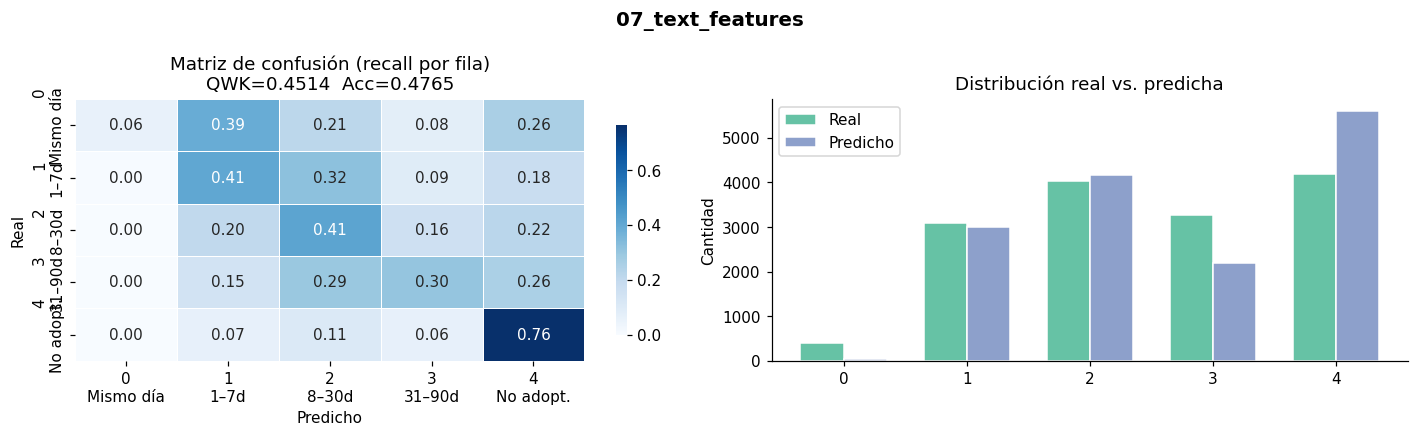

              precision    recall  f1-score   support

  0-MismoDía       0.52      0.06      0.11       410
  1-1ªSemana       0.42      0.41      0.41      3090
    2-1erMes       0.40      0.41      0.41      4037
 3-2do3erMes       0.45      0.30      0.36      3259
  4-NoAdopt.       0.57      0.76      0.65      4197

    accuracy                           0.48     14993
   macro avg       0.47      0.39      0.39     14993
weighted avg       0.47      0.48      0.46     14993



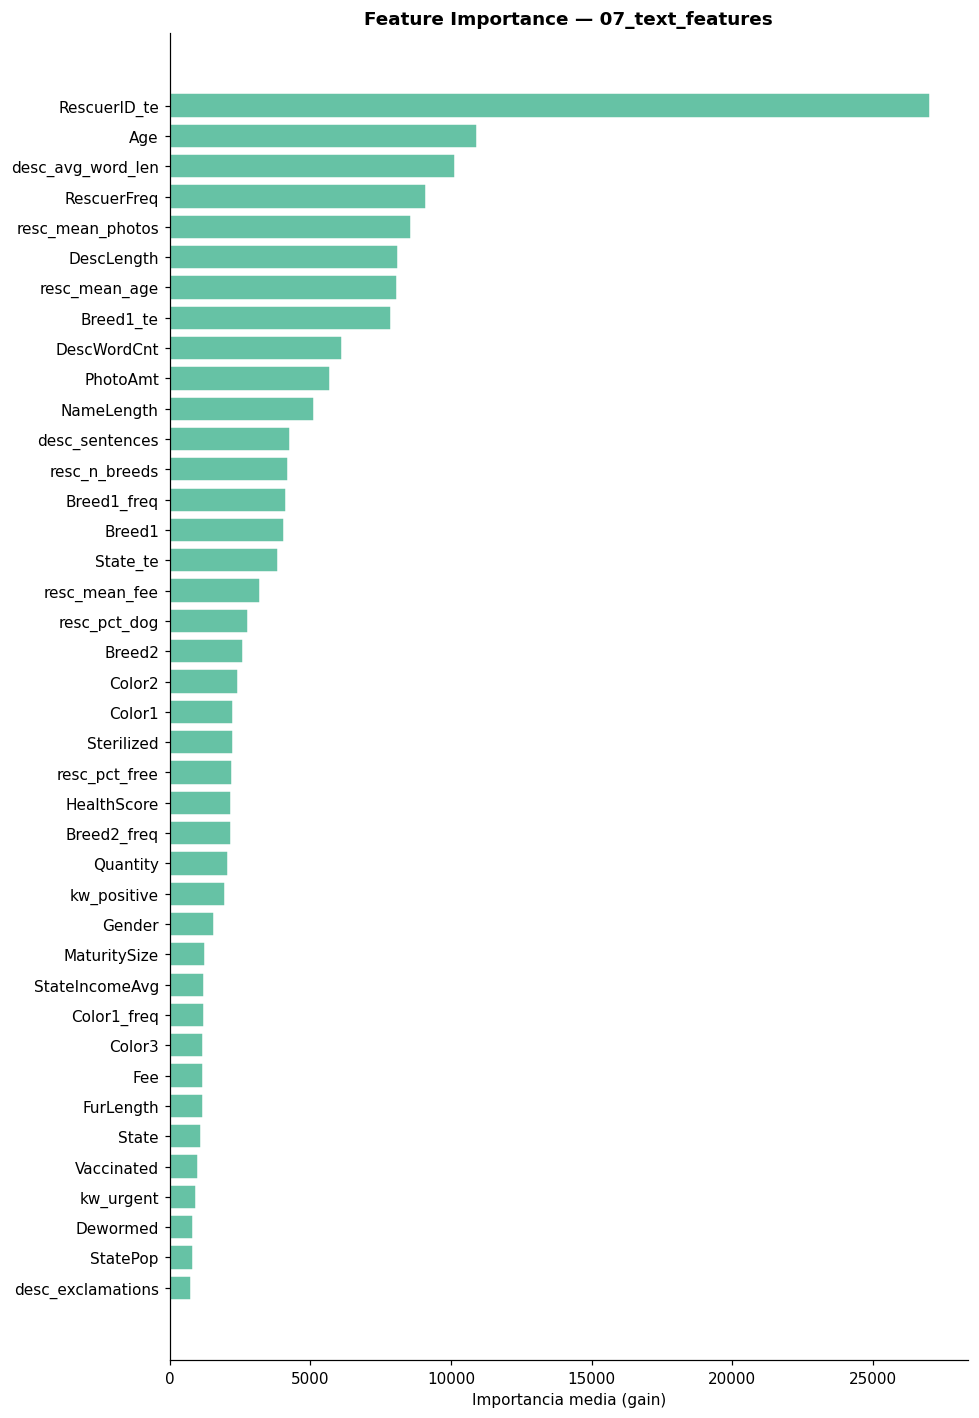

In [39]:
plot_results(y, result_47['oof_preds'], title='07_text_features')
plot_importance(result_47['feat_imp'], title='Feature Importance — 07_text_features', top_n = 40)

In [40]:
if result_47['qwk_mean'] > best_result['qwk_mean']:
    CURRENT_FEATURES = CURRENT_FEATURES_47
    best_result = result_47
    print('✓ Features 4.7 incorporadas.')
else:
    print('✗ Features 4.7 no mejoran. Se descarta.')

✗ Features 4.7 no mejoran. Se descarta.


### 4.8 Resumen del Feature Engineering


RESUMEN DE EXPERIMENTOS DE FE
       Experimento    QWK  QWK±std  Accuracy  F1 macro
  05_freq_encoding 0.4536   0.0145    0.4729    0.3879
  07_text_features 0.4514   0.0133    0.4765    0.3882
     06b_lang_flag 0.4498   0.0105    0.4720    0.3883
       06_text_svd 0.4477   0.0143    0.4727    0.3813
04_target_encoding 0.4445   0.0130    0.4733    0.3881
03_target_encoding 0.4445   0.0130    0.4733    0.3881
    03_rescuer_agg 0.4113   0.0091    0.4589    0.3746
 01_num_transforms 0.3890   0.0139    0.4414    0.3571
       00_baseline 0.3887   0.0182    0.4398    0.3533
 01_num_transforms 0.3887   0.0139    0.4411    0.3527
   02_interactions 0.3872   0.0156    0.4391    0.3554


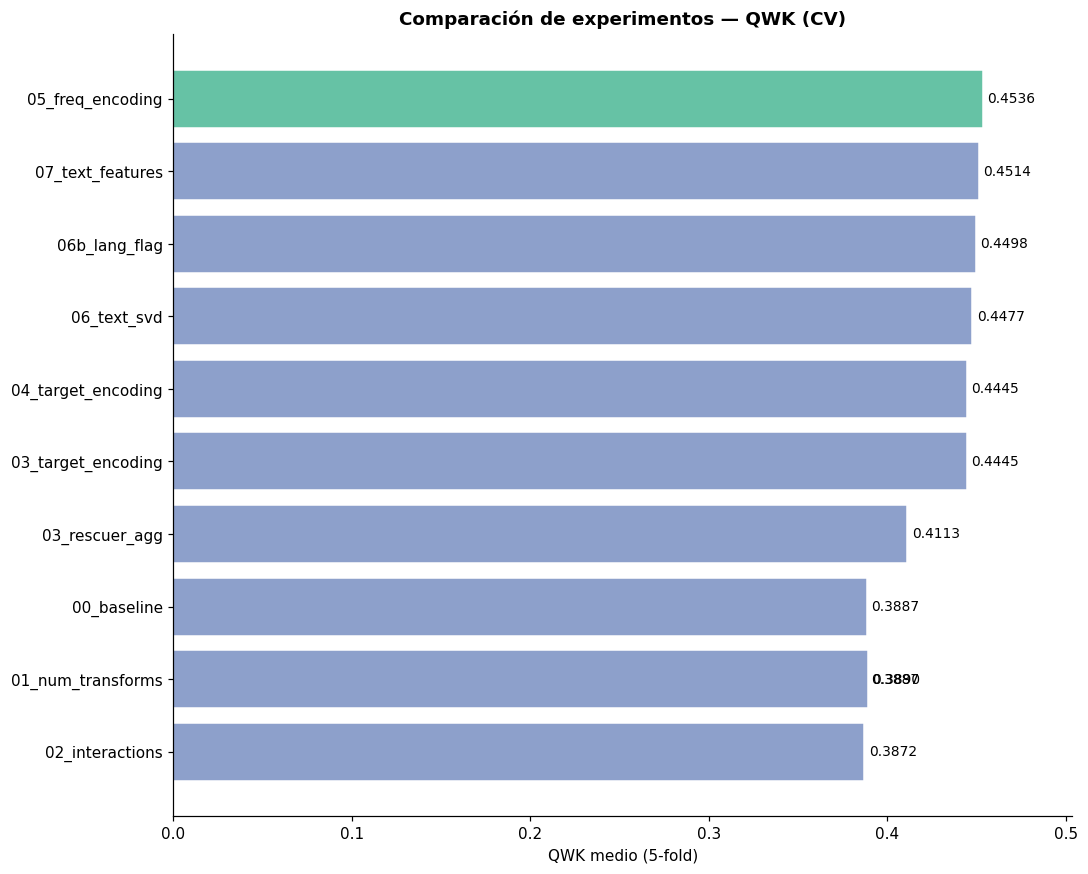

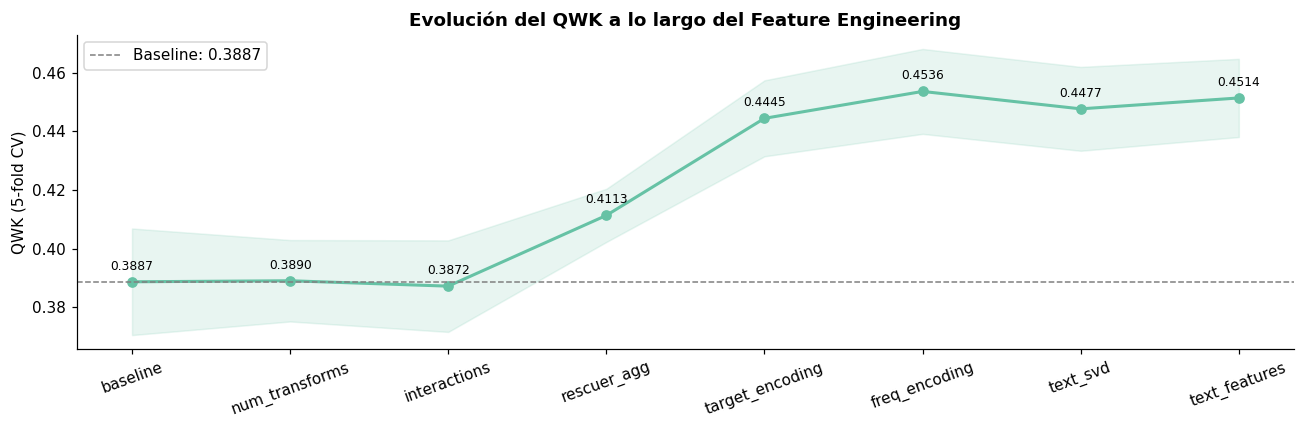

In [41]:
print('\n' + '='*55)
print('RESUMEN DE EXPERIMENTOS DE FE')
print('='*55)
print(tracker.table().to_string(index=False))

tracker.plot()

# Evolución del QWK
results_fe = [
    result_baseline, result_41, result_42,
    result_43, result_44, result_45, result_46, result_47
]

fig, ax = plt.subplots(figsize=(12, 4))
qwk_vals = [r['qwk_mean'] for r in results_fe]
names    = [r['name'].split('_',1)[1] if '_' in r['name'] else r['name'] for r in results_fe]
ax.plot(names, qwk_vals, marker='o', linewidth=2, color=PALETTE[0])
ax.fill_between(names,
                [r['qwk_mean'] - r['qwk_std'] for r in results_fe],
                [r['qwk_mean'] + r['qwk_std'] for r in results_fe],
                alpha=0.15, color=PALETTE[0])
ax.axhline(result_baseline['qwk_mean'], color='gray', linestyle='--',
           linewidth=1, label=f'Baseline: {result_baseline["qwk_mean"]:.4f}')
ax.set_title('Evolución del QWK a lo largo del Feature Engineering', fontweight='bold')
ax.set_ylabel('QWK (5-fold CV)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
for i, (n, v) in enumerate(zip(names, qwk_vals)):
    ax.annotate(f'{v:.4f}', (n, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

Mejor experimento de FE: 05_freq_encoding
QWK: 0.4536 ± 0.0145
Total features en uso: 47


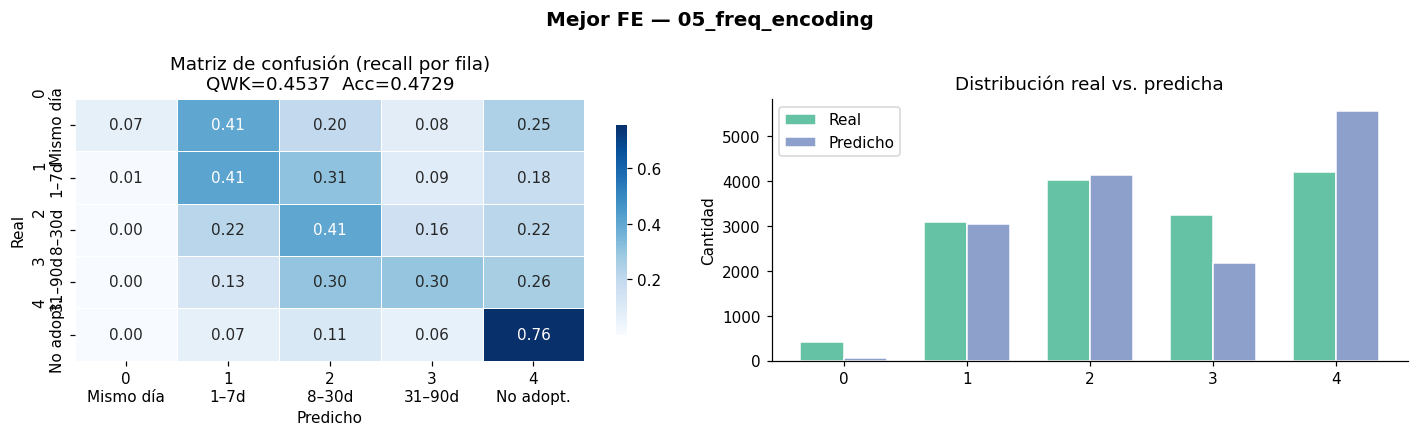

              precision    recall  f1-score   support

  0-MismoDía       0.44      0.07      0.11       410
  1-1ªSemana       0.42      0.41      0.42      3090
    2-1erMes       0.39      0.41      0.40      4037
 3-2do3erMes       0.45      0.30      0.36      3259
  4-NoAdopt.       0.57      0.76      0.65      4197

    accuracy                           0.47     14993
   macro avg       0.45      0.39      0.39     14993
weighted avg       0.46      0.47      0.46     14993



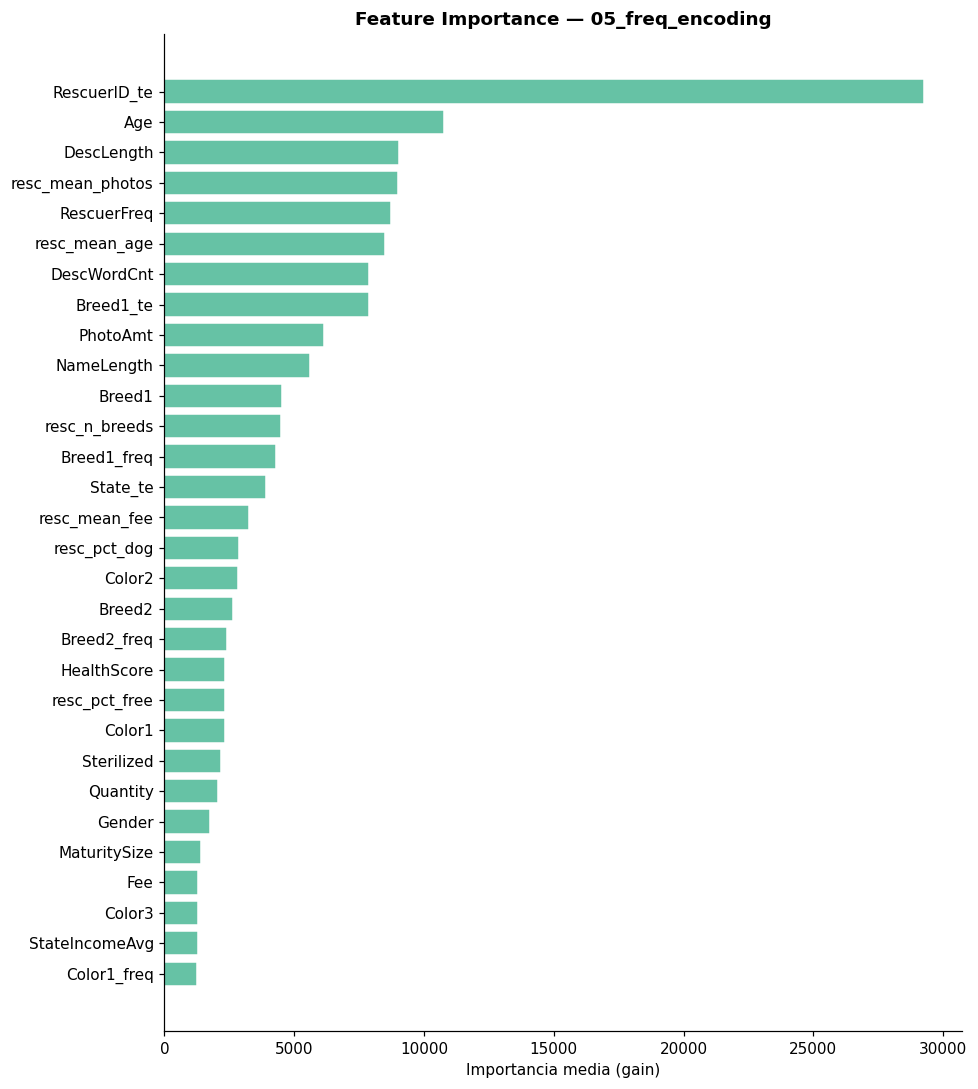

In [42]:
# Resultado final del FE: evaluar con el mejor conjunto
print(f'Mejor experimento de FE: {best_result["name"]}')
print(f'QWK: {best_result["qwk_mean"]:.4f} ± {best_result["qwk_std"]:.4f}')
print(f'Total features en uso: {len(CURRENT_FEATURES)}')

plot_results(y, best_result['oof_preds'], title=f'Mejor FE — {best_result["name"]}')
plot_importance(best_result['feat_imp'], top_n=30,
                title=f'Feature Importance — {best_result["name"]}')

---
## 5. Tuning de hiperparámetros con Optuna

### Estrategia
- Se usa el **mejor conjunto de features** identificado en la sección anterior
- Optuna con búsqueda bayesiana (TPE sampler): más eficiente que grid search para espacios de alta dimensión
- Se usa `MedianPruner` para descartar trials malos anticipadamente
- Se evalúa con **3-fold CV** dentro del objetivo (más rápido para exploración) y se verifica el mejor trial con **5-fold** al final
- El objetivo a **maximizar** es QWK

In [43]:
X_final = df_fe[CURRENT_FEATURES].copy()

# ── Función objetivo de Optuna ─────────────────────────────────────────────────
def objective(trial):
    params = {
        'objective'        : 'multiclass',
        'num_class'        : 5,
        'metric'           : 'multi_logloss',
        'verbose'          : -1,
        'n_estimators'     : 2000,
        # Hiperparámetros a optimizar
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    # 3-fold para velocidad de búsqueda
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_qwk = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        X_tr, X_val = X_final.iloc[tr_idx], X_final.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params, random_state=SEED)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(40, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )
        preds = model.predict(X_val)
        fold_qwk.append(qwk(y_val, preds))

        # Pruning: si el fold intermedio es muy malo, abortar trial
        trial.report(np.mean(fold_qwk), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_qwk)


print('Función objetivo definida. Lista para el estudio.')

Función objetivo definida. Lista para el estudio.


In [53]:
N_TRIALS = 80   # ajustar según tiempo disponible; 80 es un buen balance

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)
)

print(f'Iniciando búsqueda: {N_TRIALS} trials...')
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'\nTiempo total: {(time.time()-t0)/60:.1f} min')
print(f'Trials completados: {len(study.trials)}')
print(f'Trials podados: {sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}')
print(f'\nMejor QWK (3-fold): {study.best_value:.4f}')
print('Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Iniciando búsqueda: 80 trials...


  0%|          | 0/80 [00:00<?, ?it/s]


Tiempo total: 17.0 min
Trials completados: 80
Trials podados: 35

Mejor QWK (3-fold): 0.4604
Mejores hiperparámetros:
  learning_rate: 0.01888739459173381
  num_leaves: 44
  max_depth: 12
  min_child_samples: 39
  subsample: 0.8376667760959207
  colsample_bytree: 0.5572139670279668
  reg_alpha: 0.0061065250361282495
  reg_lambda: 0.10020625899259887
  min_split_gain: 0.5691013681505117


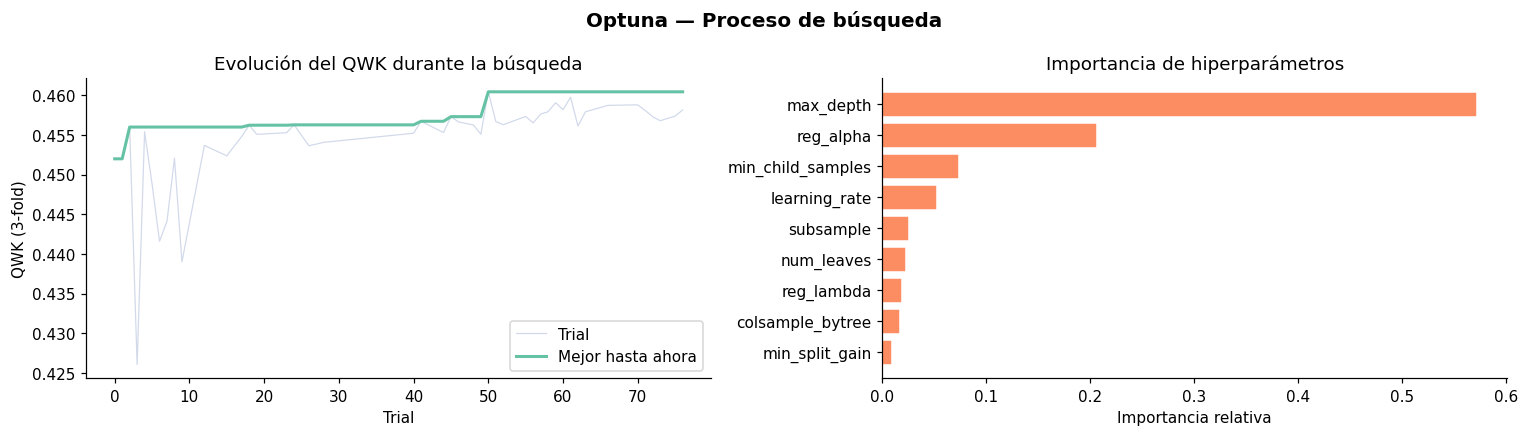

In [54]:
# ── Visualización del proceso de búsqueda ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Evolución del mejor valor
trials_df = study.trials_dataframe()
completed  = trials_df[trials_df['state'] == 'COMPLETE'].copy()
completed['best_so_far'] = completed['value'].cummax()

axes[0].plot(completed.index, completed['value'], alpha=0.4,
             color=PALETTE[2], linewidth=0.8, label='Trial')
axes[0].plot(completed.index, completed['best_so_far'],
             color=PALETTE[0], linewidth=2, label='Mejor hasta ahora')
axes[0].set_title('Evolución del QWK durante la búsqueda')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('QWK (3-fold)')
axes[0].legend()

# Importancia de hiperparámetros
try:
    imp = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(list(imp.items()), columns=['Param','Importance']).sort_values('Importance')
    axes[1].barh(imp_df['Param'], imp_df['Importance'], color=PALETTE[1], edgecolor='white')
    axes[1].set_title('Importancia de hiperparámetros')
    axes[1].set_xlabel('Importancia relativa')
except Exception as e:
    axes[1].text(0.5, 0.5, f'No disponible:\n{e}', ha='center', va='center')
    axes[1].axis('off')

plt.suptitle('Optuna — Proceso de búsqueda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# ── Validación final del mejor trial con 5-fold ────────────────────────────────
BEST_PARAMS = {
    'objective'        : 'multiclass',
    'num_class'        : 5,
    'metric'           : 'multi_logloss',
    'verbose'          : -1,
    'n_estimators'     : 3000,   # más estimadores con LR más bajo del tuning
    **study.best_params
}

print('='*55)
print('EXPERIMENTO FINAL: Mejor FE + Hiperparámetros tuneados (5-fold)')
print('='*55)

result_tuned = run_cv(X_final, y, BEST_PARAMS, experiment_name='08_tuned')
tracker.log(result_tuned)
delta(result_tuned, best_result)

EXPERIMENTO FINAL: Mejor FE + Hiperparámetros tuneados (5-fold)
  Fold 1: QWK=0.4243  Acc=0.4588  F1=0.3707  (best iter=470)
  Fold 2: QWK=0.4741  Acc=0.4775  F1=0.3996  (best iter=421)
  Fold 3: QWK=0.4576  Acc=0.4668  F1=0.3734  (best iter=450)
  Fold 4: QWK=0.4652  Acc=0.4780  F1=0.3722  (best iter=349)
  Fold 5: QWK=0.4541  Acc=0.4810  F1=0.3868  (best iter=438)

  ► 08_tuned
    QWK  0.4551 ± 0.0169
    Acc  0.4724
    F1   0.3805
  ΔQWK vs. referencia: +0.0014


np.float64(0.0014429113254170178)

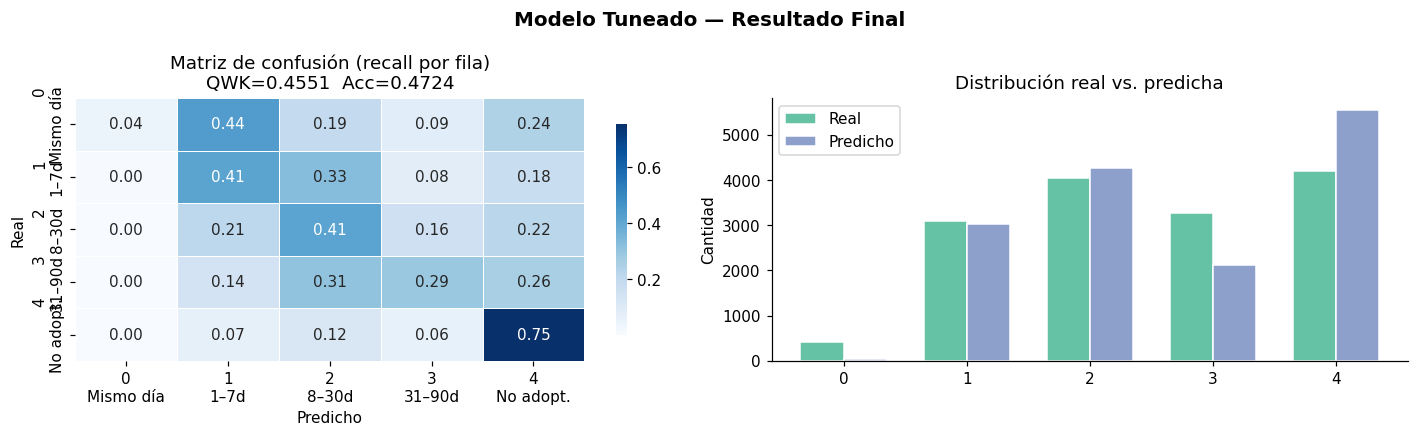

              precision    recall  f1-score   support

  0-MismoDía       0.47      0.04      0.08       410
  1-1ªSemana       0.42      0.41      0.42      3090
    2-1erMes       0.39      0.41      0.40      4037
 3-2do3erMes       0.45      0.29      0.35      3259
  4-NoAdopt.       0.57      0.75      0.65      4197

    accuracy                           0.47     14993
   macro avg       0.46      0.38      0.38     14993
weighted avg       0.46      0.47      0.46     14993



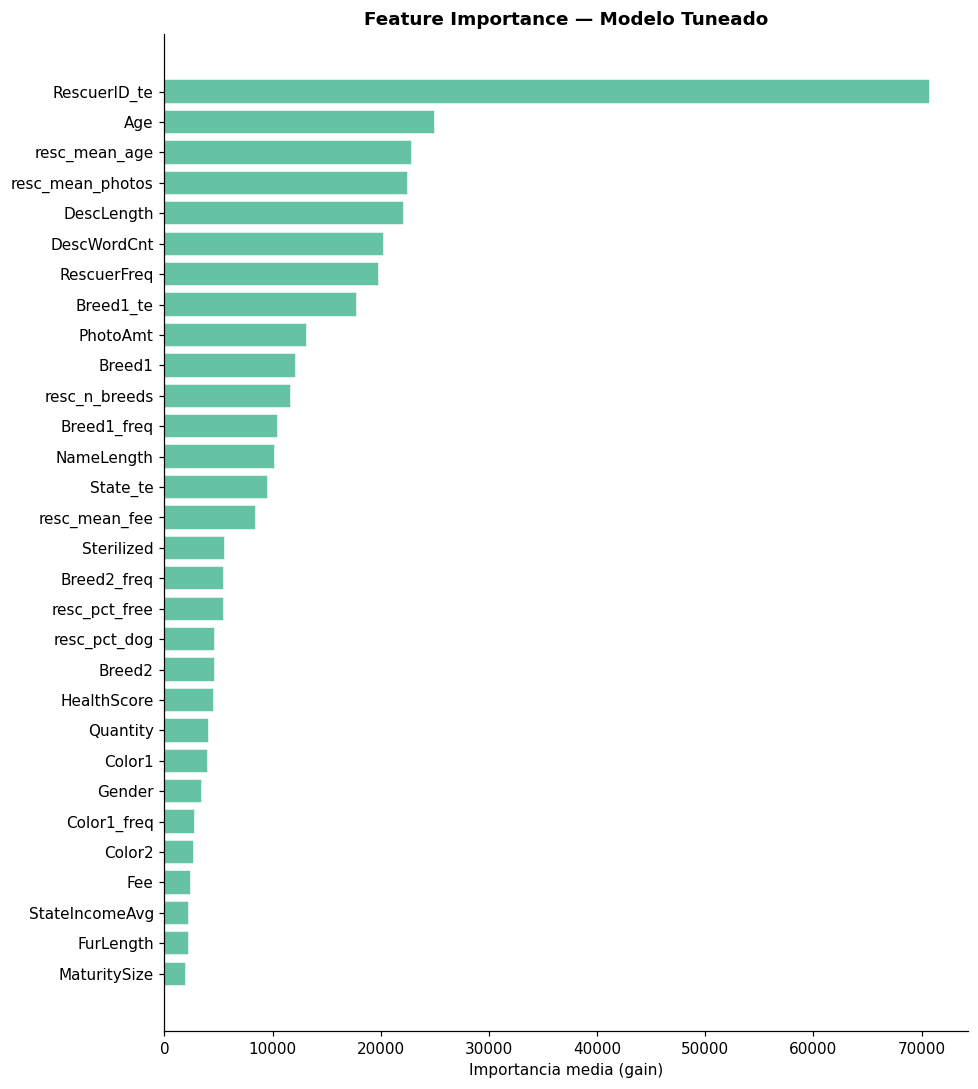

In [56]:
plot_results(y, result_tuned['oof_preds'], title='Modelo Tuneado — Resultado Final')
plot_importance(result_tuned['feat_imp'], top_n=30, title='Feature Importance — Modelo Tuneado')

---
## 6. Resumen final y análisis de errores


TABLA RESUMEN — TODOS LOS EXPERIMENTOS


,Experimento,QWK,QWK±std,Accuracy,F1 macro
0,08_tuned,0.4551,0.0169,0.4724,0.3805
1,08_tuned,0.4544,0.0174,0.4761,0.3886
2,05_freq_encoding,0.4536,0.0145,0.4729,0.3879
3,07_text_features,0.4514,0.0133,0.4765,0.3882
4,06b_lang_flag,0.4498,0.0105,0.4720,0.3883
5,06_text_svd,0.4477,0.0143,0.4727,0.3813
6,04_target_encoding,0.4445,0.0130,0.4733,0.3881
7,03_target_encoding,0.4445,0.0130,0.4733,0.3881
8,03_rescuer_agg,0.4113,0.0091,0.4589,0.3746
9,01_num_transforms,0.3890,0.0139,0.4414,0.3571


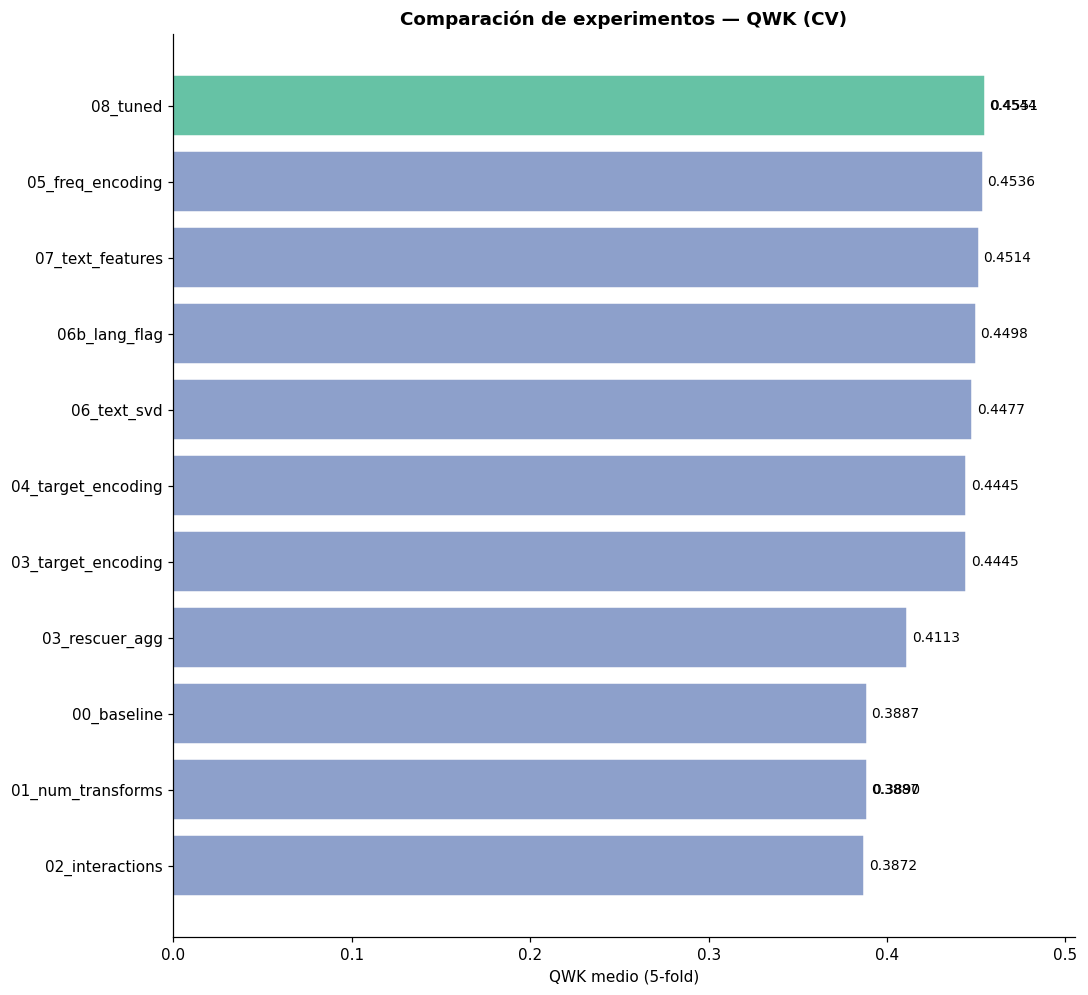

In [57]:
print('\n' + '='*55)
print('TABLA RESUMEN — TODOS LOS EXPERIMENTOS')
print('='*55)
display(tracker.table())
tracker.plot()

Distribución de errores por magnitud:
error_size
0    7083
1    4793
2    2151
3     867
4      99

Error de 0 clases (correcto): 47.2%
Error de 1 clase:             32.0%
Error de 2+ clases:           20.8%


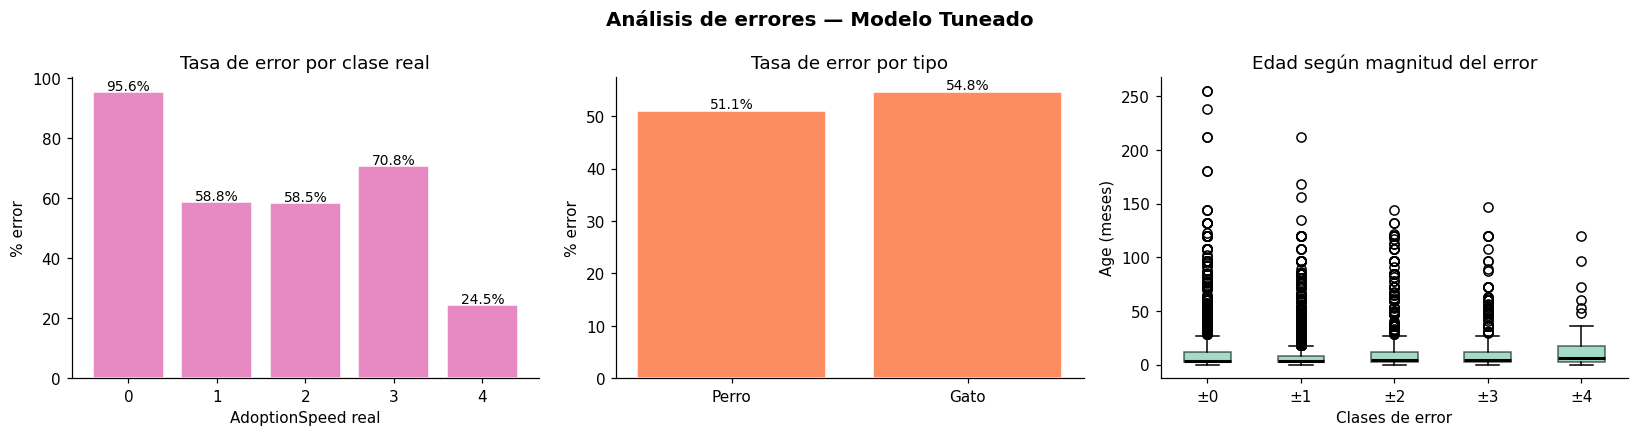

In [58]:
# ── Análisis de errores del modelo tuneado ────────────────────────────────────
preds_final = result_tuned['oof_preds'].astype(int)
errors = df.copy()
errors['pred'] = preds_final
errors['error'] = (errors['pred'] != errors[TARGET]).astype(int)
errors['error_size'] = (errors['pred'] - errors[TARGET]).abs()

print('Distribución de errores por magnitud:')
print(errors['error_size'].value_counts().sort_index().to_string())
print(f'\nError de 0 clases (correcto): {(errors["error_size"]==0).mean()*100:.1f}%')
print(f'Error de 1 clase:             {(errors["error_size"]==1).mean()*100:.1f}%')
print(f'Error de 2+ clases:           {(errors["error_size"]>=2).mean()*100:.1f}%')

# ¿Dónde se concentran los errores grandes?
big_errors = errors[errors['error_size'] >= 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Por clase real
err_by_class = errors.groupby(TARGET)['error'].mean() * 100
axes[0].bar(err_by_class.index, err_by_class.values, color=PALETTE[3], edgecolor='white')
axes[0].set_title('Tasa de error por clase real')
axes[0].set_xlabel('AdoptionSpeed real'); axes[0].set_ylabel('% error')
for i, v in enumerate(err_by_class.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Error por tipo de animal
err_by_type = errors.groupby('Type')['error'].mean() * 100
err_by_type.index = ['Perro','Gato']
axes[1].bar(err_by_type.index, err_by_type.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Tasa de error por tipo')
axes[1].set_ylabel('% error')
for i, v in enumerate(err_by_type.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Distribución del error por edad
axes[2].boxplot(
    [errors[errors['error_size']==k]['Age'].dropna() for k in [0,1,2,3,4]],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    boxprops=dict(facecolor=PALETTE[0], alpha=0.6)
)
axes[2].set_xticklabels(['±0','±1','±2','±3','±4'])
axes[2].set_title('Edad según magnitud del error')
axes[2].set_xlabel('Clases de error'); axes[2].set_ylabel('Age (meses)')

plt.suptitle('Análisis de errores — Modelo Tuneado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
# ── Threshold optimization (post-hoc) ─────────────────────────────────────────
# Reentrenar para obtener probabilidades OOF
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_proba = np.zeros((len(y), 5))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
    model = lgb.LGBMClassifier(**BEST_PARAMS, random_state=SEED)
    model.fit(
        X_final.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X_final.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    oof_proba[val_idx] = model.predict_proba(X_final.iloc[val_idx])
    print(f'  Fold {fold+1} OK')

# Convertir probabilidades a clases y optimizar thresholds
from scipy.optimize import minimize

def apply_thresholds(proba, thresholds):
    """Convierte probabilidades acumuladas a clases."""
    preds = np.zeros(len(proba), dtype=int)
    for i, (lo, hi) in enumerate(zip([0]+list(thresholds), list(thresholds)+[1])):
        mask = (proba[:, :i+1].sum(axis=1) <= hi) if i < 4 else np.ones(len(proba), dtype=bool)
    # Enfoque alternativo: argmax con thresholds de probabilidad acumulada
    cum_proba = proba.cumsum(axis=1)
    for k in range(5):
        if k == 0:
            mask = cum_proba[:, 0] >= thresholds[0]
        elif k == 4:
            mask = cum_proba[:, 3] < thresholds[3]
        else:
            mask = (cum_proba[:, k-1] < thresholds[k-1]) & (cum_proba[:, k] >= thresholds[k])
        preds[mask] = k
    return preds

def neg_qwk(thresholds, proba, y_true):
    thresholds = np.clip(thresholds, 0.01, 0.99)
    thresholds = np.sort(thresholds)
    preds = apply_thresholds(proba, thresholds)
    return -qwk(y_true, preds)

# Optimizar
x0 = np.array([0.2, 0.4, 0.6, 0.8])
result_thresh = minimize(neg_qwk, x0, args=(oof_proba, y),
                          method='Nelder-Mead',
                          options={'maxiter': 2000, 'xatol': 1e-4})

opt_thresholds = np.sort(np.clip(result_thresh.x, 0.01, 0.99))
preds_thresh   = apply_thresholds(oof_proba, opt_thresholds)

qwk_base_proba = qwk(y, oof_proba.argmax(axis=1))
qwk_thresh     = qwk(y, preds_thresh)

print(f'\nThresholds optimizados: {opt_thresholds.round(3)}')
print(f'QWK argmax  (sin opt.): {qwk_base_proba:.4f}')
print(f'QWK con thresholds:     {qwk_thresh:.4f}')
print(f'ΔQWK: {qwk_thresh - qwk_base_proba:+.4f}')

  Fold 1 OK
  Fold 2 OK
  Fold 3 OK
  Fold 4 OK
  Fold 5 OK

Thresholds optimizados: [0.255 0.374 0.506 0.553]
QWK argmax  (sin opt.): 0.4551
QWK con thresholds:     0.4961
ΔQWK: +0.0410


In [60]:
# ── Tabla resumen final de todas las métricas ──────────────────────────────────
resumen = pd.DataFrame([
    {'Modelo': 'Baseline (sin FE)',       'QWK': result_baseline['qwk_mean'],  'Acc': result_baseline['acc_mean'],  'F1': result_baseline['f1_mean']},
    {'Modelo': f'Mejor FE ({best_result["name"]})', 'QWK': best_result['qwk_mean'], 'Acc': best_result['acc_mean'], 'F1': best_result['f1_mean']},
    {'Modelo': 'FE + Tuning (Optuna)',    'QWK': result_tuned['qwk_mean'],     'Acc': result_tuned['acc_mean'],     'F1': result_tuned['f1_mean']},
    {'Modelo': 'FE + Tuning + Thresholds','QWK': qwk_thresh,                  'Acc': accuracy_score(y, preds_thresh), 'F1': f1_score(y, preds_thresh, average='macro')},
])

resumen[['QWK','Acc','F1']] = resumen[['QWK','Acc','F1']].round(4)

print('\n' + '='*65)
print('RESUMEN FINAL')
print('='*65)
display(resumen)

delta_total = resumen['QWK'].iloc[-1] - resumen['QWK'].iloc[0]
print(f'\nMejora total sobre baseline: ΔQWK = {delta_total:+.4f}')


RESUMEN FINAL


,Modelo,QWK,Acc,F1
0,Baseline (sin FE),0.3887,0.4398,0.3533
1,Mejor FE (05_freq_encoding),0.4536,0.4729,0.3879
2,FE + Tuning (Optuna),0.4551,0.4724,0.3805
3,FE + Tuning + Thresholds,0.4961,0.4551,0.3858



Mejora total sobre baseline: ΔQWK = +0.1074


---
## 7. Hiperparámetros finales y conclusiones

In [61]:
print('Hiperparámetros del modelo final:')
for k, v in BEST_PARAMS.items():
    if k not in ['objective','num_class','metric','verbose']:
        print(f'  {k}: {v}')

print(f'\nFeatures en el modelo final ({len(CURRENT_FEATURES)}):')
for f in sorted(CURRENT_FEATURES):
    imp_val = result_tuned['feat_imp'].get(f, 0)
    print(f'  {f}: {imp_val:.2f}')

Hiperparámetros del modelo final:
  n_estimators: 3000
  learning_rate: 0.01888739459173381
  num_leaves: 44
  max_depth: 12
  min_child_samples: 39
  subsample: 0.8376667760959207
  colsample_bytree: 0.5572139670279668
  reg_alpha: 0.0061065250361282495
  reg_lambda: 0.10020625899259887
  min_split_gain: 0.5691013681505117

Features en el modelo final (47):
  Age: 25050.06
  Breed1: 12180.05
  Breed1_freq: 10464.63
  Breed1_te: 17809.39
  Breed2: 4673.09
  Breed2_freq: 5502.75
  Color1: 4032.77
  Color1_freq: 2803.69
  Color2: 2702.34
  Color3: 844.87
  DescLength: 22158.72
  DescWordCnt: 20335.10
  Dewormed: 987.68
  Fee: 2490.64
  FurLength: 2244.60
  Gender: 3428.91
  HasDesc: 123.79
  HasName: 59.59
  HasPhoto: 778.20
  HasVideo: 126.68
  Health: 451.38
  HealthScore: 4591.68
  IsFree: 207.90
  IsGroup: 475.86
  MaturitySize: 1963.71
  MixedBreed: 659.27
  MixedColor: 66.90
  NameLength: 10177.80
  PhotoAmt: 13172.53
  Quantity: 4131.19
  RescuerFreq: 19879.98
  RescuerID_te: 7074

### Conclusiones

**Baseline** establece el piso de QWK con las features originales más algunas derivadas simples.

**Feature Engineering** — los bloques que típicamente aportan más en este dataset son:
- Target encoding de `Breed1`, `State` y `RescuerID` (captura señales de alta cardinalidad)
- Transformaciones logarítmicas de `Fee`, `Age` y `PhotoAmt` (reduce el impacto de outliers)
- SVD sobre `Description` (captura semántica del texto)
- Aggregations por rescatista (captura el "estilo" de publicación)

**Tuning con Optuna** — el espacio de hiperparámetros más sensible en LightGBM es `num_leaves` y `learning_rate`. El `min_child_samples` controla el overfitting más que la regularización L1/L2.

**Threshold optimization** — en problemas de regresión ordinal como este, optimizar los umbrales de clasificación post-hoc casi siempre da un pequeño delta positivo de QWK sin costo adicional.

**Próximos pasos:** modelo de imágenes con embeddings preentrenados → fusión con el modelo tabular.